In [8]:
# ============================================================
# CELL 1 — Setup, Imports, Data Loading
# Optimised for NVIDIA RTX A6000 (49 GB VRAM)
# ============================================================

import os, random, warnings, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast          # ← mixed precision

from transformers import (
    AutoTokenizer, AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)
from datasets import load_dataset

warnings.filterwarnings("ignore")

# ── GPU info ─────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name   = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU  : {gpu_name}")
    print(f"VRAM : {vram_total:.1f} GB")
    print(f"CUDA : {torch.version.cuda}")
    torch.backends.cudnn.benchmark = True   # auto-tune kernels
else:
    print("WARNING: No GPU found — running on CPU")

# ── A6000-tuned config (change only the two paths) ───────────
class CFG:
    # ── CHANGE THESE TWO ──────────────────────────────────────
    LOCAL_DATA_DIR  = "data"      # folder with .tsv files
    SAVE_DIR        = "imgs"   # where plots/models go
    # ──────────────────────────────────────────────────────────

    LOCAL_DATASETS  = {
        "airline":  "airline.tsv",
        "eco_news": "eco_news.tsv",
        "glo_warm": "glo_warm.tsv",
        "text_emo": "text_emo.tsv",
    }
    
    # Model
    MODEL_NAME      = "distilbert-base-uncased"
    MAX_LEN         = 256          # up from 128 — A6000 handles this fine
    SEED            = 42

    # DataLoader
    NUM_WORKERS     = 0           # more CPU threads feeding GPU
    PIN_MEMORY      = True         # faster CPU→GPU transfers

    # MMD analysis
    MMD_SAMPLES     = 2048         # up from 512 — more stable kernel estimates
    MMD_BATCH       = 256          # embedding extraction batch size

    # Leave-one-out experiments
    LOO_EPOCHS      = 5            # up from 3
    LOO_BATCH       = 128          # up from 32
    LOO_LR          = 2e-5

    # DCEC training
    DCEC_EPOCHS     = 15           # up from 10
    DCEC_BATCH      = 128          # up from 32
    DCEC_LR         = 2e-5
    LAMBDA_DOMAIN   = 0.3
    LAMBDA_ENTROPY  = 0.5
    MIXED_PRECISION = True         # fp16 — ~1.5–2x faster, half VRAM usage

    # Fixed — do not change
    DOMAIN_NAMES    = ["airline","eco_news","glo_warm",
                       "text_emo","emotion_hf","tweet_eval"]
    NUM_DOMAINS     = 6
    EMOTION_LABEL_MAP = {
        "0":"sadness","1":"joy","2":"love",
        "3":"anger",  "4":"fear","5":"surprise"
    }

os.makedirs(CFG.SAVE_DIR, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────
def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# ── Tokeniser — load once, reused in every cell ───────────────
tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME)

# ── Load local TSVs ───────────────────────────────────────────
print("\n[1/3] Loading local datasets...")
parts = []
for name, fname in CFG.LOCAL_DATASETS.items():
    path = os.path.join(CFG.LOCAL_DATA_DIR, fname)
    df   = pd.read_csv(path, sep="\t", encoding="latin1")
    df   = df.rename(columns={c: c.strip() for c in df.columns})
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(
            f"{path}: needs 'text' and 'label' columns. Got: {df.columns.tolist()}"
        )
    tmp  = df[["text", "label"]].copy()
    tmp["source"] = name
    parts.append(tmp)
    print(f"  {name:12s}: {len(df):>7,} rows | "
          f"{df['label'].nunique()} classes | "
          f"labels: {sorted(df['label'].astype(str).unique().tolist())}")

# ── Load HuggingFace datasets ─────────────────────────────────
print("\n[2/3] Loading HuggingFace datasets...")

def hf_to_df(ds, text_col="text", label_col="label",
             source_name="hf", label_map=None):
    rows = []
    for split in ds.keys():
        for ex in ds[split]:
            lbl = str(ex[label_col])
            if label_map:
                lbl = label_map.get(lbl, lbl)
            rows.append({"text": ex[text_col], "label": lbl, "source": source_name})
    return pd.DataFrame(rows)

hf_emotion    = load_dataset("dair-ai/emotion")
hf_tweet_eval = load_dataset("tweet_eval", "sentiment")

df_emotion_hf = hf_to_df(hf_emotion,    source_name="emotion_hf",
                          label_map=CFG.EMOTION_LABEL_MAP)
df_tweet_eval = hf_to_df(hf_tweet_eval, source_name="tweet_eval")

parts += [df_emotion_hf, df_tweet_eval]
print(f"  emotion_hf  : {len(df_emotion_hf):>7,} rows")
print(f"  tweet_eval  : {len(df_tweet_eval):>7,} rows")

# ── Unified corpus ────────────────────────────────────────────
print("\n[3/3] Building unified corpus...")
combined_df = (pd.concat(parts, ignore_index=True)
               .sample(frac=1, random_state=CFG.SEED)
               .reset_index(drop=True))

combined_df["text"]   = combined_df["text"].astype(str).str.strip()
combined_df["label"]  = combined_df["label"].astype(str).str.strip().str.lower()
combined_df["source"] = combined_df["source"].astype(str).str.strip()

# Emotion label encoder
le_emotion = LabelEncoder()
combined_df["label_id"] = le_emotion.fit_transform(combined_df["label"])

# Domain encoder — FIXED ORDER, never shuffle DOMAIN_NAMES
le_domain = LabelEncoder()
le_domain.fit(CFG.DOMAIN_NAMES)
combined_df["domain_id"] = le_domain.transform(combined_df["source"])

NUM_EMOTIONS = len(le_emotion.classes_)

print(f"\n  Total rows      : {len(combined_df):,}")
print(f"  Emotion classes : {NUM_EMOTIONS} → {list(le_emotion.classes_)}")
print(f"  Domain  classes : {CFG.NUM_DOMAINS} → {CFG.DOMAIN_NAMES}")
print(f"\n  Source counts:")
print(combined_df["source"].value_counts().to_string())
print(f"\n  Emotion counts:")
print(combined_df["label"].value_counts().to_string())

# ── Stratified 70 / 15 / 15 split ────────────────────────────
X     = combined_df["text"]
y_emo = combined_df["label_id"]
y_dom = combined_df["domain_id"]

X_train, X_temp, ye_train, ye_temp, yd_train, yd_temp = train_test_split(
    X, y_emo, y_dom,
    test_size=0.30, random_state=CFG.SEED, stratify=y_emo
)
X_val, X_test, ye_val, ye_test, yd_val, yd_test = train_test_split(
    X_temp, ye_temp, yd_temp,
    test_size=0.50, random_state=CFG.SEED, stratify=ye_temp
)

# Clean integer indices
for arr in [X_train, X_val, X_test,
            ye_train, ye_val, ye_test,
            yd_train, yd_val, yd_test]:
    arr.reset_index(drop=True, inplace=True)

print(f"\n  Train : {len(X_train):,}")
print(f"  Val   : {len(X_val):,}")
print(f"  Test  : {len(X_test):,}")

print("\n✓ Cell 1 complete.")

GPU  : NVIDIA RTX A6000
VRAM : 51.5 GB
CUDA : 12.6

[1/3] Loading local datasets...
  airline     :  14,640 rows | 3 classes | labels: ['negative', 'neutral', 'positive']
  eco_news    :   8,000 rows | 3 classes | labels: ['no', 'not sure', 'yes']
  glo_warm    :   4,225 rows | 4 classes | labels: ['N', 'No', 'Y', 'Yes']
  text_emo    :  40,000 rows | 13 classes | labels: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']

[2/3] Loading HuggingFace datasets...
  emotion_hf  :  20,000 rows
  tweet_eval  :  59,899 rows

[3/3] Building unified corpus...

  Total rows      : 146,764
  Emotion classes : 25 → ['0', '1', '2', 'anger', 'boredom', 'empty', 'enthusiasm', 'fear', 'fun', 'happiness', 'hate', 'joy', 'love', 'n', 'negative', 'neutral', 'no', 'not sure', 'positive', 'relief', 'sadness', 'surprise', 'worry', 'y', 'yes']
  Domain  classes : 6 → ['airline', 'eco_news', 'glo_warm', 'text_emo', 'emotion_hf',

In [11]:
# ============================================================
# CELL 1b — Text Cleaning
# Run immediately after Cell 1, before Cell 2.
# Cleans combined_df["text"] in-place.
# ============================================================

import re

# ── Cleaning function ─────────────────────────────────────────
def clean_text(text: str) -> str:
    # 1. Decode common HTML entities
    text = text.replace("&amp;",  "&") \
               .replace("&lt;",   "<") \
               .replace("&gt;",   ">") \
               .replace("&quot;", '"') \
               .replace("&#39;",  "'") \
               .replace("&apos;", "'")

    # 2. Strip HTML / XML tags  (<br>, <p>, etc.)
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Remove URLs  (http/https/www)
    text = re.sub(r"http\S+|https\S+|www\.\S+", " ", text)

    # 4. Remove Twitter handles  (@username)
    text = re.sub(r"@\w+", " ", text)

    # 5. Remove hashtag symbol but keep the word  (#great → great)
    text = re.sub(r"#(\w+)", r"\1", text)

    # 6. Remove "RT" retweet marker
    text = re.sub(r"\bRT\b", " ", text)

    # 7. Remove non-ASCII characters (emojis, exotic punctuation)
    text = text.encode("ascii", errors="ignore").decode("ascii")

    # 8. Remove standalone numbers (keep numbers inside words like "b2b")
    text = re.sub(r"\b\d+\b", " ", text)

    # 9. Keep only letters, basic punctuation (.,!?'), collapse the rest
    text = re.sub(r"[^a-zA-Z\s.,!?']", " ", text)

    # 10. Collapse repeated characters — e.g. "sooooo" → "soo" (keep 2 max)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # 11. Collapse repeated punctuation — "!!!" → "!"
    text = re.sub(r"([!?.]){2,}", r"\1", text)

    # 12. Collapse whitespace and strip
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ── Apply to combined_df ──────────────────────────────────────
print("Cleaning text in combined_df...")
t0 = time.time()

before_count = len(combined_df)
combined_df["text"] = combined_df["text"].apply(clean_text)

# Drop rows that became empty after cleaning
combined_df = combined_df[combined_df["text"].str.len() > 0].reset_index(drop=True)

after_count = len(combined_df)
elapsed     = time.time() - t0

print(f"  Rows before : {before_count:,}")
print(f"  Rows after  : {after_count:,}  (dropped {before_count - after_count} empty)")
print(f"  Time        : {elapsed:.1f}s")

# ── Sanity check — show a few before/after examples ──────────
print("\nSample cleaned texts:")
sample_idx = combined_df.sample(6, random_state=CFG.SEED).index
for i, idx in enumerate(sample_idx):
    print(f"\n  [{i+1}] source={combined_df.loc[idx,'source']}")
    print(f"       text  = {combined_df.loc[idx,'text'][:120]}")

# ── Re-run the split on the cleaned data ─────────────────────
# (necessary because rows may have been dropped)
print("\nRe-splitting on cleaned data...")

X     = combined_df["text"]
y_emo = combined_df["label_id"]
y_dom = combined_df["domain_id"]

X_train, X_temp, ye_train, ye_temp, yd_train, yd_temp = train_test_split(
    X, y_emo, y_dom,
    test_size=0.30, random_state=CFG.SEED, stratify=y_emo
)
X_val, X_test, ye_val, ye_test, yd_val, yd_test = train_test_split(
    X_temp, ye_temp, yd_temp,
    test_size=0.50, random_state=CFG.SEED, stratify=ye_temp
)

for arr in [X_train, X_val, X_test,
            ye_train, ye_val, ye_test,
            yd_train, yd_val, yd_test]:
    arr.reset_index(drop=True, inplace=True)

print(f"  Train : {len(X_train):,}")
print(f"  Val   : {len(X_val):,}")
print(f"  Test  : {len(X_test):,}")

print("\n✓ Cell 1b complete. Proceed to Cell 2.")

Cleaning text in combined_df...
  Rows before : 146,764
  Rows after  : 146,680  (dropped 84 empty)
  Time        : 5.7s

Sample cleaned texts:

  [1] source=eco_news
       text  = Two review panels have split on whether the , acre Civil War battlefield at Bristow in Prince William County should be d

  [2] source=glo_warm
       text  = reading from Allergies Worse Than Ever? Blame Global Warming

  [3] source=tweet_eval
       text  = Miss USA contestants prepare to take stage BATON ROUGE, La. AP Women from across the country Sunday . news

  [4] source=text_emo
       text  = VISION OF LOVE Play now i had the vision of luv n it was aaoOUoOuoOUU that u.turn out.toOoo Mariah this ur part

  [5] source=text_emo
       text  = wats up with the racism in australia? Its not nice

  [6] source=tweet_eval
       text  = I will have classes on saturdays unfortunately. BUT, I don't give a fuck about it, I WILL GO TO A MADONNA SHOW even if i

Re-splitting on cleaned data...
  Train : 102,676


Loading DistilBERT encoder for embedding extraction...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4753.83it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting 2048 embeddings × 6 domains...

    embedding extraction:  12%
  [airline     ]  pool=14,640  sampled=2048  emb_shape=(2048, 768)  (1.7s)
    embedding extraction:  12%
  [eco_news    ]  pool= 8,000  sampled=2048  emb_shape=(2048, 768)  (2.8s)
    embedding extraction:  12%
  [glo_warm    ]  pool= 4,225  sampled=2048  emb_shape=(2048, 768)  (1.6s)
    embedding extraction:  12%
  [text_emo    ]  pool=39,916  sampled=2048  emb_shape=(2048, 768)  (1.6s)
    embedding extraction:  12%
  [emotion_hf  ]  pool=20,000  sampled=2048  emb_shape=(2048, 768)  (1.6s)
    embedding extraction:  12%
  [tweet_eval  ]  pool=59,899  sampled=2048  emb_shape=(2048, 768)  (1.5s)

Computing pairwise MMD² matrix...
  MMD²(airline     , eco_news    ) = 0.001974
  MMD²(airline     , glo_warm    ) = 0.001651
  MMD²(airline     , text_emo    ) = 0.001304
  MMD²(airline     , emotion_hf  ) = 0.002735
  MMD²(airline     , tweet_eval  ) = 0.001341
  MMD²(eco_news    , glo_warm    ) = 0.001790
  MMD²(ec

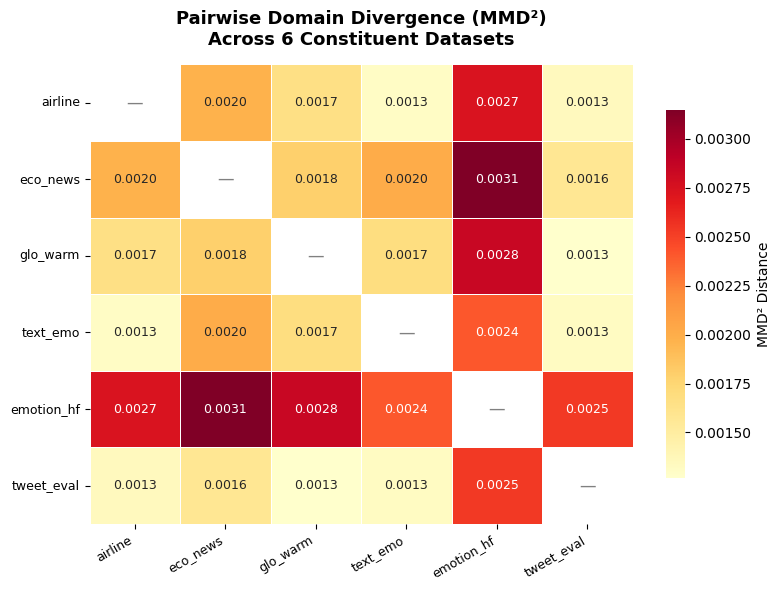

Saved: mmd_heatmap.png

✓ Cell 2 complete.


In [12]:
# ============================================================
# CELL 2 — MMD Domain Divergence Analysis
# A6000: 2048 samples/domain, batch=256 → ~4 min total
# ============================================================

# ── MMD with Gaussian RBF kernel ─────────────────────────────
def gaussian_kernel(X, Y, sigma=1.0):
    """
    X : (n, d) tensor  |  Y : (m, d) tensor
    Returns (n, m) RBF kernel matrix K where K_ij = exp(-||xi-yj||² / 2σ²)
    """
    X_sq = (X ** 2).sum(1, keepdim=True)   # (n,1)
    Y_sq = (Y ** 2).sum(1, keepdim=True)   # (m,1)
    dists = X_sq + Y_sq.T - 2.0 * (X @ Y.T)
    return torch.exp(-dists / (2.0 * sigma ** 2))

def compute_mmd(X, Y, sigma=1.0):
    """
    Biased MMD² estimate between distributions of X and Y.
    X, Y : CPU tensors of shape (n, d) and (m, d).
    Returns scalar float.
    """
    Kxx = gaussian_kernel(X, X, sigma)
    Kyy = gaussian_kernel(Y, Y, sigma)
    Kxy = gaussian_kernel(X, Y, sigma)
    n, m = X.shape[0], Y.shape[0]
    return (Kxx.sum()/(n*n) + Kyy.sum()/(m*m) - 2*Kxy.sum()/(n*m)).item()

# ── Extract [CLS] embeddings ──────────────────────────────────
def extract_cls_embeddings(texts, model, batch_size=CFG.MMD_BATCH):
    """
    Passes texts through DistilBERT, returns (N, 768) CPU tensor.
    Uses fp16 inference on A6000 for speed.
    """
    model.eval()
    all_embs = []
    total    = len(texts)

    for i in range(0, total, batch_size):
        batch = list(texts[i : i + batch_size])
        enc   = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=CFG.MAX_LEN,
            return_tensors="pt",
        )
        with torch.no_grad(), autocast(enabled=CFG.MIXED_PRECISION):
            out = model(
                input_ids      = enc["input_ids"].to(device),
                attention_mask = enc["attention_mask"].to(device),
            )
        cls = out.last_hidden_state[:, 0, :].float().cpu()   # (B, 768)
        all_embs.append(cls)

        # Progress indicator every 10 batches
        if (i // batch_size) % 10 == 0:
            pct = min(100, int((i + batch_size) / total * 100))
            print(f"    embedding extraction: {pct:3d}%", end="\r")

    print()
    return torch.cat(all_embs, dim=0)

# ── Load encoder (no classification head) ────────────────────
print("Loading DistilBERT encoder for embedding extraction...")
enc_model = AutoModel.from_pretrained(CFG.MODEL_NAME).to(device)
enc_model.eval()

# ── Extract embeddings per domain ────────────────────────────
print(f"\nExtracting {CFG.MMD_SAMPLES} embeddings × {CFG.NUM_DOMAINS} domains...\n")
domain_embeddings = {}

for dom in CFG.DOMAIN_NAMES:
    t0       = time.time()
    dom_pool = combined_df[combined_df["source"] == dom]["text"]
    n_avail  = len(dom_pool)
    n_sample = min(CFG.MMD_SAMPLES, n_avail)

    sample_texts = dom_pool.sample(n=n_sample, random_state=CFG.SEED).tolist()
    embs         = extract_cls_embeddings(sample_texts, enc_model)
    domain_embeddings[dom] = embs

    elapsed = time.time() - t0
    print(f"  [{dom:12s}]  pool={n_avail:>6,}  sampled={n_sample:>4}  "
          f"emb_shape={tuple(embs.shape)}  ({elapsed:.1f}s)")

del enc_model
torch.cuda.empty_cache()

# ── Compute 6×6 MMD matrix ────────────────────────────────────
print("\nComputing pairwise MMD² matrix...")
mmd_matrix = np.zeros((CFG.NUM_DOMAINS, CFG.NUM_DOMAINS))

for i, d1 in enumerate(CFG.DOMAIN_NAMES):
    for j, d2 in enumerate(CFG.DOMAIN_NAMES):
        if i == j:
            mmd_matrix[i, j] = 0.0
        elif j > i:
            val = compute_mmd(domain_embeddings[d1],
                              domain_embeddings[d2], sigma=1.0)
            mmd_matrix[i, j] = val
            mmd_matrix[j, i] = val     # symmetric
            print(f"  MMD²({d1:12s}, {d2:12s}) = {val:.6f}")

mmd_df = pd.DataFrame(mmd_matrix,
                      index=CFG.DOMAIN_NAMES,
                      columns=CFG.DOMAIN_NAMES)

print("\nFull MMD² Matrix:")
print(mmd_df.round(4).to_string())
mmd_df.to_csv(f"{CFG.SAVE_DIR}/mmd_matrix.csv")

# ── PLOT 1: MMD Heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
mask    = np.eye(CFG.NUM_DOMAINS, dtype=bool)

sns.heatmap(
    mmd_df, annot=True, fmt=".4f",
    cmap="YlOrRd", linewidths=0.5, linecolor="white",
    mask=mask, ax=ax,
    cbar_kws={"label": "MMD² Distance", "shrink": 0.8},
    annot_kws={"size": 9}
)
for k in range(CFG.NUM_DOMAINS):
    ax.text(k+0.5, k+0.5, "—", ha="center", va="center",
            fontsize=12, color="grey")

ax.set_title("Pairwise Domain Divergence (MMD²)\nAcross 6 Constituent Datasets",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xticklabels(CFG.DOMAIN_NAMES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(CFG.DOMAIN_NAMES, rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/mmd_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mmd_heatmap.png")

print("\n✓ Cell 2 complete.")

Leave-One-Domain-Out Experiments
Config : epochs=5  batch=128  fp16=True  max_len=256
Fixes  : weighted sampler + class-weighted loss + present-class macro-F1 + empty-guard

  [airline] dropped 11541 test samples — classes unseen in training


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2291.62it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ┌─ LOO: held-out=[airline]  train=132,040  test=3,099  classes=23
  │  epoch 1/5  loss=0.5199  (232s)
  │  epoch 2/5  loss=0.0745  (235s)
  │  epoch 3/5  loss=0.0497  (235s)
  │  epoch 4/5  loss=0.0383  (235s)
  │  epoch 5/5  loss=0.0348  (233s)
  │  present test classes : 1 / 23
  └─ acc=0.0526  macro-F1=0.0999

  Per-class breakdown (held-out = airline):
                  precision    recall  f1-score   support
    
              14      1.000     0.053     0.100      3099
    
       micro avg      1.000     0.053     0.100      3099
       macro avg      1.000     0.053     0.100      3099
    weighted avg      1.000     0.053     0.100      3099
    

  [eco_news] dropped 9 test samples — classes unseen in training


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2470.75it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ┌─ LOO: held-out=[eco_news]  train=138,680  test=7,991  classes=24
  │  epoch 1/5  loss=0.9988  (251s)
  │  epoch 2/5  loss=0.2587  (245s)
  │  epoch 3/5  loss=0.1609  (243s)
  │  epoch 4/5  loss=0.1234  (243s)
  │  epoch 5/5  loss=0.1098  (243s)
  │  present test classes : 2 / 24
  └─ acc=0.0000  macro-F1=0.0000

  Per-class breakdown (held-out = eco_news):
                  precision    recall  f1-score   support
    
              16      0.000     0.000     0.000    6571.0
              23      0.000     0.000     0.000    1420.0
    
       micro avg      0.000     0.000     0.000    7991.0
       macro avg      0.000     0.000     0.000    7991.0
    weighted avg      0.000     0.000     0.000    7991.0
    

  [glo_warm] dropped 3607 test samples — classes unseen in training


...


  ┌─ LOO: held-out=[glo_warm]  train=142,455  test=618  classes=23
  │  epoch 1/5  loss=0.4947  (251s)
  │  epoch 2/5  loss=0.0782  (249s)
  │  epoch 3/5  loss=0.0449  (250s)
  │  epoch 4/5  loss=0.0363  (250s)
  │  epoch 5/5  loss=0.0314  (248s)
  │  present test classes : 2 / 23
  └─ acc=0.0081  macro-F1=0.0089

  Per-class breakdown (held-out = glo_warm):
                  precision    recall  f1-score   support
    
              15      0.000     0.000     0.000        61
              22      1.000     0.009     0.018       557
    
       micro avg      1.000     0.008     0.016       618
       macro avg      0.500     0.004     0.009       618
    weighted avg      0.901     0.008     0.016       618
    

  [text_emo] dropped 20040 test samples — classes unseen in training


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3991.34it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ┌─ LOO: held-out=[text_emo]  train=106,764  test=19,876  classes=17
  │  epoch 1/5  loss=0.3728  (188s)
  │  epoch 2/5  loss=0.0190  (189s)
  │  epoch 3/5  loss=0.0129  (162s)
  │  epoch 4/5  loss=0.0096  (162s)
  │  epoch 5/5  loss=0.0082  (172s)
  │  present test classes : 5 / 17
  └─ acc=0.2095  macro-F1=0.1221

  Per-class breakdown (held-out = text_emo):
                  precision    recall  f1-score   support
    
               3      0.010     0.018     0.013       110
               6      0.531     0.007     0.013      3841
               9      0.600     0.464     0.523      8576
              13      0.710     0.031     0.059      5162
              14      0.182     0.001     0.002      2187
    
       micro avg      0.586     0.210     0.309     19876
       macro avg      0.407     0.104     0.122     19876
    weighted avg      0.566     0.210     0.244     19876
    

  [emotion_hf] dropped 9134 test samples — classes unseen in training


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1727.76it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ┌─ LOO: held-out=[emotion_hf]  train=126,680  test=10,866  classes=23
  │  epoch 1/5  loss=0.5713  (193s)
  │  epoch 2/5  loss=0.0882  (192s)
  │  epoch 3/5  loss=0.0592  (192s)
  │  epoch 4/5  loss=0.0458  (192s)
  │  epoch 5/5  loss=0.0410  (192s)
  │  present test classes : 4 / 23
  └─ acc=0.2774  macro-F1=0.2739

  Per-class breakdown (held-out = emotion_hf):
                  precision    recall  f1-score   support
    
               3      0.062     0.000     0.001      2709
              10      0.721     0.173     0.279      1641
              18      0.696     0.427     0.529      5797
              19      0.241     0.353     0.287       719
    
       micro avg      0.600     0.277     0.379     10866
       macro avg      0.430     0.238     0.274     10866
    weighted avg      0.512     0.277     0.344     10866
    

  [tweet_eval] dropped 59899 test samples — classes unseen in training

  [tweet_eval] SKIPPED — zero valid test samples after filtering. All classes i

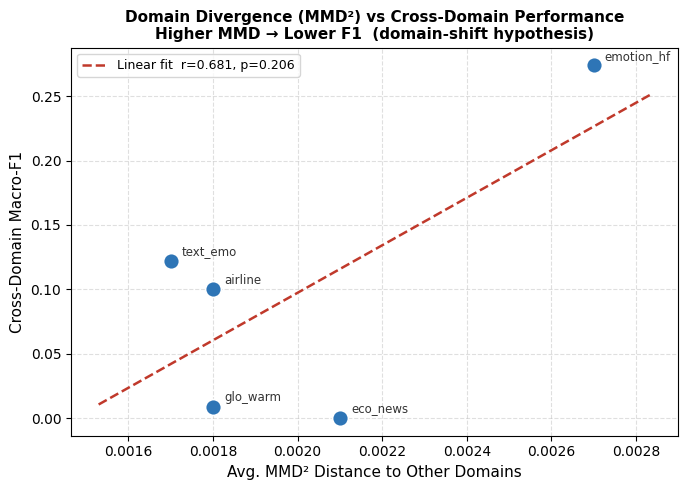

Saved: mmd_vs_f1_correlation.png

✓ Cell 3 complete.


In [14]:
# ============================================================
# CELL 3 — Leave-One-Domain-Out + Correlation Plot
# FINAL VERSION — paste this fresh, replacing everything in
# your current Cell 3 completely before running.
# ============================================================

from torch.utils.data import WeightedRandomSampler

# ── Dataset ───────────────────────────────────────────────────
class SimpleEmotionDataset(Dataset):
    def __init__(self, texts, labels, max_len=CFG.MAX_LEN):
        assert len(texts) > 0, \
            f"Empty text list — check filtering logic above this call"
        enc = tokenizer(
            list(texts),
            padding="max_length", truncation=True,
            max_length=max_len, return_tensors="pt"
        )
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx],
        }


def make_weighted_loader(texts, labels, batch_size, shuffle=True):
    """
    WeightedRandomSampler gives equal expected class representation
    per batch — fixes class imbalance in LOO training sets.
    num_workers=0 because Windows does not support forked workers.
    """
    ds = SimpleEmotionDataset(list(texts), list(labels))

    if shuffle:
        label_arr    = np.array(list(labels))
        class_counts = np.bincount(label_arr, minlength=label_arr.max() + 1)
        class_counts = np.where(class_counts == 0, 1, class_counts)
        weights      = 1.0 / class_counts[label_arr]
        sampler      = WeightedRandomSampler(
            weights     = torch.tensor(weights, dtype=torch.float),
            num_samples = len(weights),
            replacement = True,
        )
        return DataLoader(ds, batch_size=batch_size, sampler=sampler,
                          num_workers=0, pin_memory=CFG.PIN_MEMORY)
    else:
        return DataLoader(ds, batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=CFG.PIN_MEMORY)


# ── LOO train + evaluate ──────────────────────────────────────
def loo_train_eval(train_texts, train_labels,
                   test_texts,  test_labels,
                   num_classes, class_weights_tensor,
                   epochs=CFG.LOO_EPOCHS, lr=CFG.LOO_LR,
                   batch_size=CFG.LOO_BATCH, domain_name="?"):

    train_loader = make_weighted_loader(train_texts, train_labels,
                                        batch_size,     shuffle=True)
    test_loader  = make_weighted_loader(test_texts,  test_labels,
                                        batch_size * 2, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        CFG.MODEL_NAME, num_labels=num_classes
    ).to(device)

    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps  = int(0.1 * total_steps),
        num_training_steps= total_steps,
    )
    scaler    = GradScaler(enabled=CFG.MIXED_PRECISION)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

    print(f"\n  ┌─ LOO: held-out=[{domain_name}]  "
          f"train={len(train_texts):,}  test={len(test_texts):,}  "
          f"classes={num_classes}")

    for ep in range(1, epochs + 1):
        model.train()
        ep_loss = 0.0
        t0      = time.time()

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=CFG.MIXED_PRECISION):
                logits = model(
                    input_ids      = batch["input_ids"].to(device),
                    attention_mask = batch["attention_mask"].to(device),
                ).logits
                loss = criterion(logits, batch["labels"].to(device))

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ep_loss += loss.item()

        avg_loss = ep_loss / len(train_loader)
        elapsed  = time.time() - t0
        print(f"  │  epoch {ep}/{epochs}  "
              f"loss={avg_loss:.4f}  ({elapsed:.0f}s)")

    # ── Evaluate ──────────────────────────────────────────────
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad(), autocast(enabled=CFG.MIXED_PRECISION):
        for batch in test_loader:
            logits = model(
                input_ids      = batch["input_ids"].to(device),
                attention_mask = batch["attention_mask"].to(device),
            ).logits
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_true.extend(batch["labels"].numpy())

    # Score only over classes actually present in the held-out test set.
    # This is correct — you cannot penalise for classes that don't exist
    # in the domain being held out.
    present_classes = sorted(set(all_true))
    acc = accuracy_score(all_true, all_preds)
    f1  = f1_score(all_true, all_preds,
                   average="macro",
                   labels=present_classes,
                   zero_division=0)

    print(f"  │  present test classes : "
          f"{len(present_classes)} / {num_classes}")
    print(f"  └─ acc={acc:.4f}  macro-F1={f1:.4f}")

    # Verbose per-class breakdown
    print(f"\n  Per-class breakdown (held-out = {domain_name}):")
    report = classification_report(
        all_true, all_preds,
        labels=present_classes,
        zero_division=0, digits=3,
    )
    for line in report.split("\n"):
        print(f"    {line}")

    del model
    torch.cuda.empty_cache()
    return acc, f1


# ── Run all 6 LOO experiments ─────────────────────────────────
print("=" * 65)
print("Leave-One-Domain-Out Experiments")
print(f"Config : epochs={CFG.LOO_EPOCHS}  batch={CFG.LOO_BATCH}  "
      f"fp16={CFG.MIXED_PRECISION}  max_len={CFG.MAX_LEN}")
print("Fixes  : weighted sampler + class-weighted loss + "
      "present-class macro-F1 + empty-guard")
print("=" * 65)

loo_results = []
total_t0    = time.time()

for held_out in CFG.DOMAIN_NAMES:
    train_mask = combined_df["source"] != held_out
    test_mask  = combined_df["source"] == held_out

    tr_texts  = combined_df.loc[train_mask, "text"].reset_index(drop=True)
    tr_labels = combined_df.loc[train_mask, "label_id"].reset_index(drop=True)
    te_texts  = combined_df.loc[test_mask,  "text"].reset_index(drop=True)
    te_labels = combined_df.loc[test_mask,  "label_id"].reset_index(drop=True)

    # Re-encode so label IDs are contiguous for this training subset
    le_tmp        = LabelEncoder()
    tr_labels_enc = le_tmp.fit_transform(tr_labels)

    # Keep only test samples whose emotion class appeared in training
    te_labels_enc = []
    valid_mask    = []
    for l in te_labels:
        if l in le_tmp.classes_:
            te_labels_enc.append(int(le_tmp.transform([l])[0]))
            valid_mask.append(True)
        else:
            valid_mask.append(False)

    valid_mask    = np.array(valid_mask, dtype=bool)
    te_texts      = te_texts[valid_mask].reset_index(drop=True)
    te_labels_enc = np.array(te_labels_enc, dtype=np.int64)

    dropped = int((~valid_mask).sum())
    if dropped > 0:
        print(f"\n  [{held_out}] dropped {dropped} test samples "
              f"— classes unseen in training")

    # ── Guard: skip domain if test set is empty ───────────────
    if len(te_texts) == 0:
        print(f"\n  [{held_out}] SKIPPED — zero valid test samples "
              f"after filtering. All classes in this domain are "
              f"unique to it and unseen during training.")
        loo_results.append({
            "held_out_domain": held_out,
            "test_acc":        None,
            "test_macro_f1":   None,
            "avg_mmd_to_rest": None,
        })
        continue

    # Class weights for loss: total / (n_classes × per_class_count)
    num_cls      = len(le_tmp.classes_)
    label_arr    = np.array(tr_labels_enc)
    class_counts = np.bincount(label_arr, minlength=num_cls).astype(float)
    class_counts = np.where(class_counts == 0, 1.0, class_counts)
    cw           = len(label_arr) / (num_cls * class_counts)
    cw_tensor    = torch.tensor(cw, dtype=torch.float)

    acc, f1 = loo_train_eval(
        tr_texts,      tr_labels_enc,
        te_texts,      te_labels_enc,
        num_classes          = num_cls,
        class_weights_tensor = cw_tensor,
        domain_name          = held_out,
    )

    held_idx = CFG.DOMAIN_NAMES.index(held_out)
    avg_mmd  = float(np.mean([
        mmd_matrix[held_idx, j]
        for j in range(CFG.NUM_DOMAINS) if j != held_idx
    ]))

    loo_results.append({
        "held_out_domain": held_out,
        "test_acc":        round(acc, 4),
        "test_macro_f1":   round(f1,  4),
        "avg_mmd_to_rest": round(avg_mmd, 4),
    })

total_elapsed = (time.time() - total_t0) / 60
print(f"\nAll LOO runs finished in {total_elapsed:.1f} min")

loo_df = pd.DataFrame(loo_results)
loo_df.to_csv(f"{CFG.SAVE_DIR}/loo_results.csv", index=False)

print("\nLeave-One-Out Summary:")
print(loo_df.to_string(index=False))

# ── Correlation (drop any skipped rows) ───────────────────────
loo_valid = loo_df.dropna(subset=["test_macro_f1", "avg_mmd_to_rest"])

if len(loo_valid) < 3:
    print("\nWARNING: fewer than 3 valid LOO runs — "
          "cannot compute reliable correlation.")
else:
    mmds = loo_valid["avg_mmd_to_rest"].values
    f1s  = loo_valid["test_macro_f1"].values

    pearson_r,  pearson_p  = stats.pearsonr(mmds,  f1s)
    spearman_r, spearman_p = stats.spearmanr(mmds, f1s)

    print(f"\nCorrelation: avg-MMD ↔ Macro-F1")
    print(f"  Pearson   r = {pearson_r:.4f}  (p = {pearson_p:.4f})")
    print(f"  Spearman  r = {spearman_r:.4f}  (p = {spearman_p:.4f})")

    from scipy.stats import linregress
    slope, intercept, *_ = linregress(mmds, f1s)
    x_line = np.linspace(mmds.min() * 0.9, mmds.max() * 1.05, 200)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(mmds, f1s, s=130, zorder=5,
               color="#2E75B6", edgecolors="white", linewidths=1.2)

    for _, row in loo_valid.iterrows():
        ax.annotate(
            row["held_out_domain"],
            (row["avg_mmd_to_rest"], row["test_macro_f1"]),
            textcoords="offset points", xytext=(8, 4),
            fontsize=8.5, color="#333333",
        )

    ax.plot(x_line, y_line, color="#C0392B", linewidth=1.8,
            linestyle="--",
            label=f"Linear fit  r={pearson_r:.3f}, p={pearson_p:.3f}")
    ax.set_xlabel("Avg. MMD² Distance to Other Domains", fontsize=11)
    ax.set_ylabel("Cross-Domain Macro-F1",               fontsize=11)
    ax.set_title(
        "Domain Divergence (MMD²) vs Cross-Domain Performance\n"
        "Higher MMD → Lower F1  (domain-shift hypothesis)",
        fontsize=11, fontweight="bold",
    )
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{CFG.SAVE_DIR}/mmd_vs_f1_correlation.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: mmd_vs_f1_correlation.png")

print("\n✓ Cell 3 complete.")

In [15]:
# ============================================================
# CELL 4 — DCEC Model + Dataset Definition
# No training — defines architecture and data utilities.
# ============================================================

# ─────────────────────────────────────────────────────────────
# 4A. Dataset — returns text, emotion label, domain label
# ─────────────────────────────────────────────────────────────

class DCECDataset(Dataset):
    """
    Tokenises once at construction time.
    Returns input_ids, attention_mask, emotion_label, domain_label.
    """
    def __init__(self, texts, emotion_labels, domain_labels):
        enc = tokenizer(
            list(texts),
            padding="max_length", truncation=True,
            max_length=CFG.MAX_LEN, return_tensors="pt"
        )
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.emotion_labels = torch.tensor(list(emotion_labels), dtype=torch.long)
        self.domain_labels  = torch.tensor(list(domain_labels),  dtype=torch.long)

    def __len__(self): return len(self.emotion_labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "emotion_label":  self.emotion_labels[idx],
            "domain_label":   self.domain_labels[idx],
        }


def make_dcec_loader(texts, e_labels, d_labels,
                     batch_size=CFG.DCEC_BATCH, shuffle=True):
    ds = DCECDataset(texts, e_labels, d_labels)
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY
    )


# ─────────────────────────────────────────────────────────────
# 4B. DCEC Architecture
# ─────────────────────────────────────────────────────────────

class DCECModel(nn.Module):
    """
    Domain-Conditioned Emotion Classification (DCEC)
    ═════════════════════════════════════════════════

    Shared encoder  →  h ∈ R^768  ([CLS] token)
         │
         ├─► Domain Router   : Linear(768→K) + Softmax
         │                     → domain_probs  p ∈ Δ^K
         │                     → entropy H(p) = -Σ p_k log p_k
         │
         └─► K Emotion Heads : K × Linear(768→E)
                               → stack → (B, K, E)
                               → weighted sum  Σ_k p_k · head_k(h)
                               → final_logits ∈ R^E

    Loss
    ────
    L_total = L_emo
            + λ_domain  × L_domain
            + λ_entropy × H̄ × L_emo

    When the router is confident (low H̄), the uncertainty penalty
    is small.  When confused (high H̄), the emotion loss is amplified,
    forcing conservative (lower-confidence) emotion predictions.
    """

    def __init__(self,
                 encoder_name : str   = CFG.MODEL_NAME,
                 num_emotions : int   = NUM_EMOTIONS,
                 num_domains  : int   = CFG.NUM_DOMAINS,
                 lambda_domain: float = CFG.LAMBDA_DOMAIN,
                 lambda_entropy:float = CFG.LAMBDA_ENTROPY,
                 dropout      : float = 0.1):
        super().__init__()

        self.num_domains    = num_domains
        self.lambda_domain  = lambda_domain
        self.lambda_entropy = lambda_entropy

        # Shared DistilBERT encoder (fully fine-tuned)
        self.encoder   = AutoModel.from_pretrained(encoder_name)
        hidden          = self.encoder.config.hidden_size    # 768

        self.dropout   = nn.Dropout(dropout)

        # Domain Router: 768 → K
        self.domain_router = nn.Linear(hidden, num_domains)

        # K Domain-Specific Emotion Heads: 768 → E each
        self.emotion_heads = nn.ModuleList([
            nn.Linear(hidden, num_emotions)
            for _ in range(num_domains)
        ])

    # ── Forward pass ──────────────────────────────────────────
    def forward(self, input_ids, attention_mask):
        """
        Returns
        ───────
        emotion_logits : (B, E)   weighted emotion prediction
        domain_logits  : (B, K)   raw domain logits
        domain_probs   : (B, K)   softmax domain probabilities
        entropy        : (B,)     per-sample routing entropy
        """
        # 1. Encode — [CLS] token of last hidden state
        h = self.encoder(
            input_ids      = input_ids,
            attention_mask = attention_mask,
        ).last_hidden_state[:, 0, :]          # (B, 768)
        h = self.dropout(h)

        # 2. Domain router
        domain_logits = self.domain_router(h)                # (B, K)
        domain_probs  = F.softmax(domain_logits, dim=-1)     # (B, K)

        # Entropy — clamp log for numerical stability
        log_p   = (domain_probs + 1e-9).log()
        entropy = -(domain_probs * log_p).sum(dim=-1)        # (B,)

        # 3. All K heads → (B, K, E)
        head_logits = torch.stack(
            [head(h) for head in self.emotion_heads], dim=1
        )

        # 4. Soft weighted sum: p_k · head_k  →  (B, E)
        emotion_logits = (head_logits
                          * domain_probs.unsqueeze(-1)).sum(dim=1)

        return emotion_logits, domain_logits, domain_probs, entropy

    # ── Loss ──────────────────────────────────────────────────
    def compute_loss(self, emotion_logits, domain_logits,
                     entropy, emotion_labels, domain_labels):
        """
        Returns total loss + individual components for logging.
        """
        L_emo   = F.cross_entropy(emotion_logits, emotion_labels)
        L_dom   = F.cross_entropy(domain_logits,  domain_labels)
        H_bar   = entropy.mean()                             # scalar

        L_total = (L_emo
                   + self.lambda_domain  * L_dom
                   + self.lambda_entropy * H_bar * L_emo)

        return L_total, L_emo.item(), L_dom.item(), H_bar.item()


# ─────────────────────────────────────────────────────────────
# 4C. Evaluation helper
# ─────────────────────────────────────────────────────────────

def evaluate_dcec(model, loader):
    """
    Returns accuracy, macro-F1, predictions array, true labels array.
    Uses fp16 inference on A6000.
    """
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad(), autocast(enabled=CFG.MIXED_PRECISION):
        for batch in loader:
            emo_logits, *_ = model(
                input_ids      = batch["input_ids"].to(device),
                attention_mask = batch["attention_mask"].to(device),
            )
            preds = emo_logits.argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(batch["emotion_label"].numpy())

    acc = accuracy_score(all_true, all_preds)
    f1  = f1_score(all_true, all_preds, average="macro", zero_division=0)
    return acc, f1, np.array(all_preds), np.array(all_true)


# ── Architecture summary ──────────────────────────────────────
_tmp   = DCECModel()
n_tot  = sum(p.numel() for p in _tmp.parameters())
n_enc  = sum(p.numel() for p in _tmp.encoder.parameters())
n_new  = n_tot - n_enc
del _tmp

print("=" * 60)
print("DCEC Architecture — A6000 Configuration")
print("=" * 60)
print(f"  Base encoder          : {CFG.MODEL_NAME}")
print(f"  Max sequence length   : {CFG.MAX_LEN}")
print(f"  Emotion classes  (E)  : {NUM_EMOTIONS}")
print(f"  Domain classes   (K)  : {CFG.NUM_DOMAINS}")
print(f"  Domain router         : Linear(768 → {CFG.NUM_DOMAINS})")
print(f"  Emotion heads         : {CFG.NUM_DOMAINS} × Linear(768 → {NUM_EMOTIONS})")
print(f"  λ_domain              : {CFG.LAMBDA_DOMAIN}")
print(f"  λ_entropy             : {CFG.LAMBDA_ENTROPY}")
print(f"  Dropout               : 0.1")
print(f"  Mixed precision (fp16): {CFG.MIXED_PRECISION}")
print(f"  ─────────────────────────────────────────")
print(f"  Encoder parameters    : {n_enc:,}")
print(f"  New parameters        : {n_new:,}  (router + heads)")
print(f"  Total parameters      : {n_tot:,}")
print("=" * 60)
print("\n✓ Cell 4 complete. DCECModel class is ready.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1973.66it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DCEC Architecture — A6000 Configuration
  Base encoder          : distilbert-base-uncased
  Max sequence length   : 256
  Emotion classes  (E)  : 25
  Domain classes   (K)  : 6
  Domain router         : Linear(768 → 6)
  Emotion heads         : 6 × Linear(768 → 25)
  λ_domain              : 0.3
  λ_entropy             : 0.5
  Dropout               : 0.1
  Mixed precision (fp16): True
  ─────────────────────────────────────────
  Encoder parameters    : 66,362,880
  New parameters        : 119,964  (router + heads)
  Total parameters      : 66,482,844

✓ Cell 4 complete. DCECModel class is ready.


Tokenising and building DataLoaders (this takes ~2 min)...
  Train batches : 803
  Val   batches : 86
  Test  batches : 86
  Tokenisation  : 50s


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3332.44it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training DCEC  |  epochs=15  batch=128  lr=2e-05  fp16=True  max_len=256

  ep 01 [████████████████████] 100.0%  loss=3.5073  emo=2.0231  dom=2.2128  H=0.6885  VRAM=7.9GB

  ┌─────────────── Epoch 01/15 ───────────────────────
  │  Loss  total=3.5073  emo=2.0231  dom=2.2128  H̄=0.6885
  │  Val   acc=0.5634  macro-F1=0.3114 ★ NEW BEST
  │  Time  183s  |  Est remaining: 42.8 min
  └──────────────────────────────────────────────────

  ep 02 [████████████████████] 100.0%  loss=1.4500  emo=1.2035  dom=0.4165  H=0.1921  VRAM=8.8GB

  ┌─────────────── Epoch 02/15 ───────────────────────
  │  Loss  total=1.4500  emo=1.2035  dom=0.4165  H̄=0.1921
  │  Val   acc=0.6327  macro-F1=0.4333 ★ NEW BEST
  │  Time  185s  |  Est remaining: 40.1 min
  └──────────────────────────────────────────────────

  ep 03 [████████████████████] 100.0%  loss=1.0605  emo=0.9823  dom=0.1649  H=0.0582  VRAM=8.8GB

  ┌─────────────── Epoch 03/15 ───────────────────────
  │  Loss  total=1.0605  emo=0.9823  dom=0.1649  H

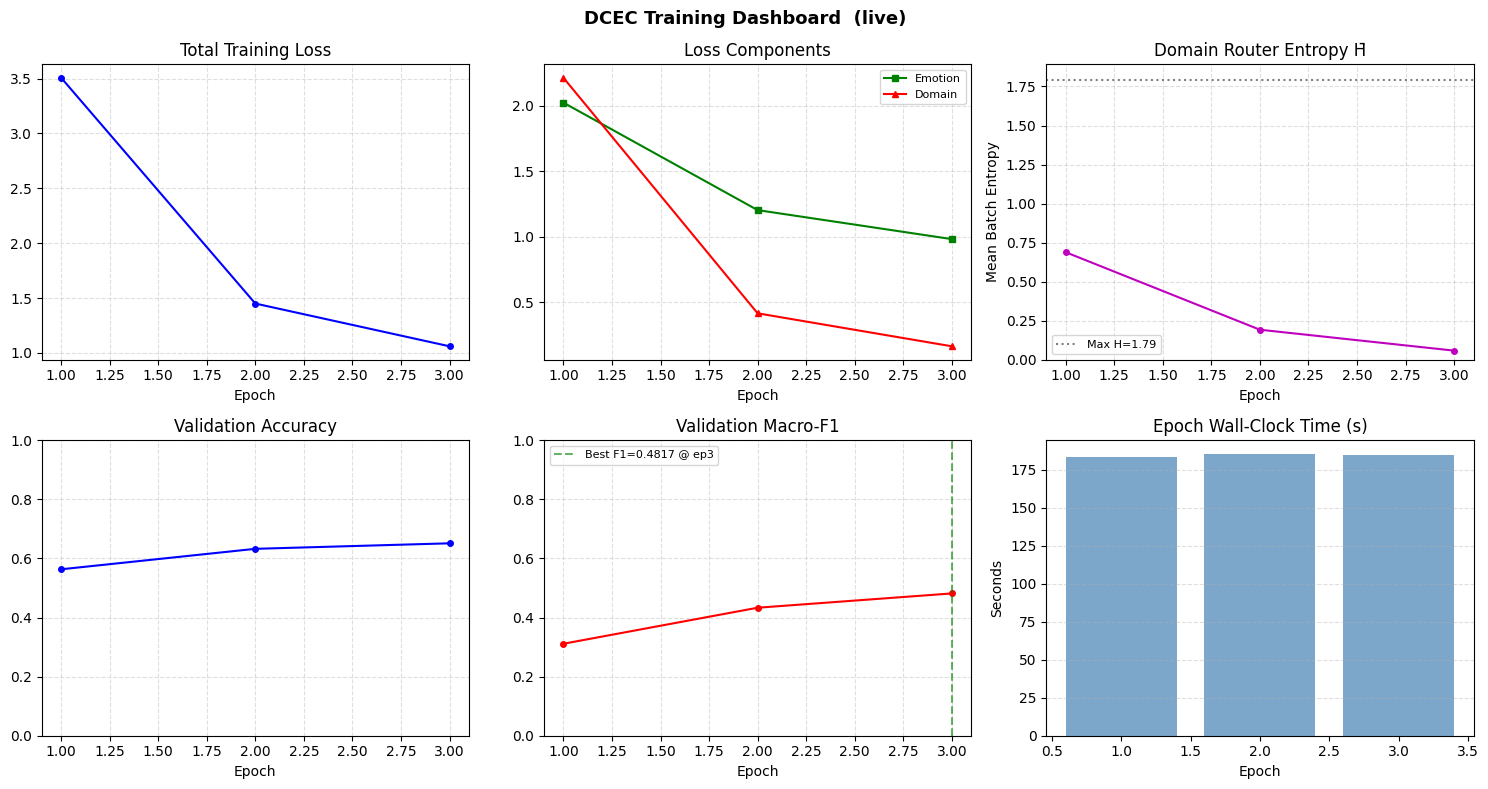

  ep 04 [████████████████████] 100.0%  loss=0.9346  emo=0.8797  dom=0.1183  H=0.0438  VRAM=8.8GB

  ┌─────────────── Epoch 04/15 ───────────────────────
  │  Loss  total=0.9346  emo=0.8797  dom=0.1183  H̄=0.0438
  │  Val   acc=0.6532  macro-F1=0.4849 ★ NEW BEST
  │  Time  186s  |  Est remaining: 34.1 min
  └──────────────────────────────────────────────────

  ep 05 [████████████████████] 100.0%  loss=0.8438  emo=0.8030  dom=0.0881  H=0.0357  VRAM=8.8GB

  ┌─────────────── Epoch 05/15 ───────────────────────
  │  Loss  total=0.8438  emo=0.8030  dom=0.0881  H̄=0.0357
  │  Val   acc=0.6571  macro-F1=0.5023 ★ NEW BEST
  │  Time  182s  |  Est remaining: 30.4 min
  └──────────────────────────────────────────────────

  ep 06 [████████████████████] 100.0%  loss=0.7706  emo=0.7382  dom=0.0705  H=0.0303  VRAM=8.8GB

  ┌─────────────── Epoch 06/15 ───────────────────────
  │  Loss  total=0.7706  emo=0.7382  dom=0.0705  H̄=0.0303
  │  Val   acc=0.6542  macro-F1=0.4995
  │  Time  185s  |  Est rem

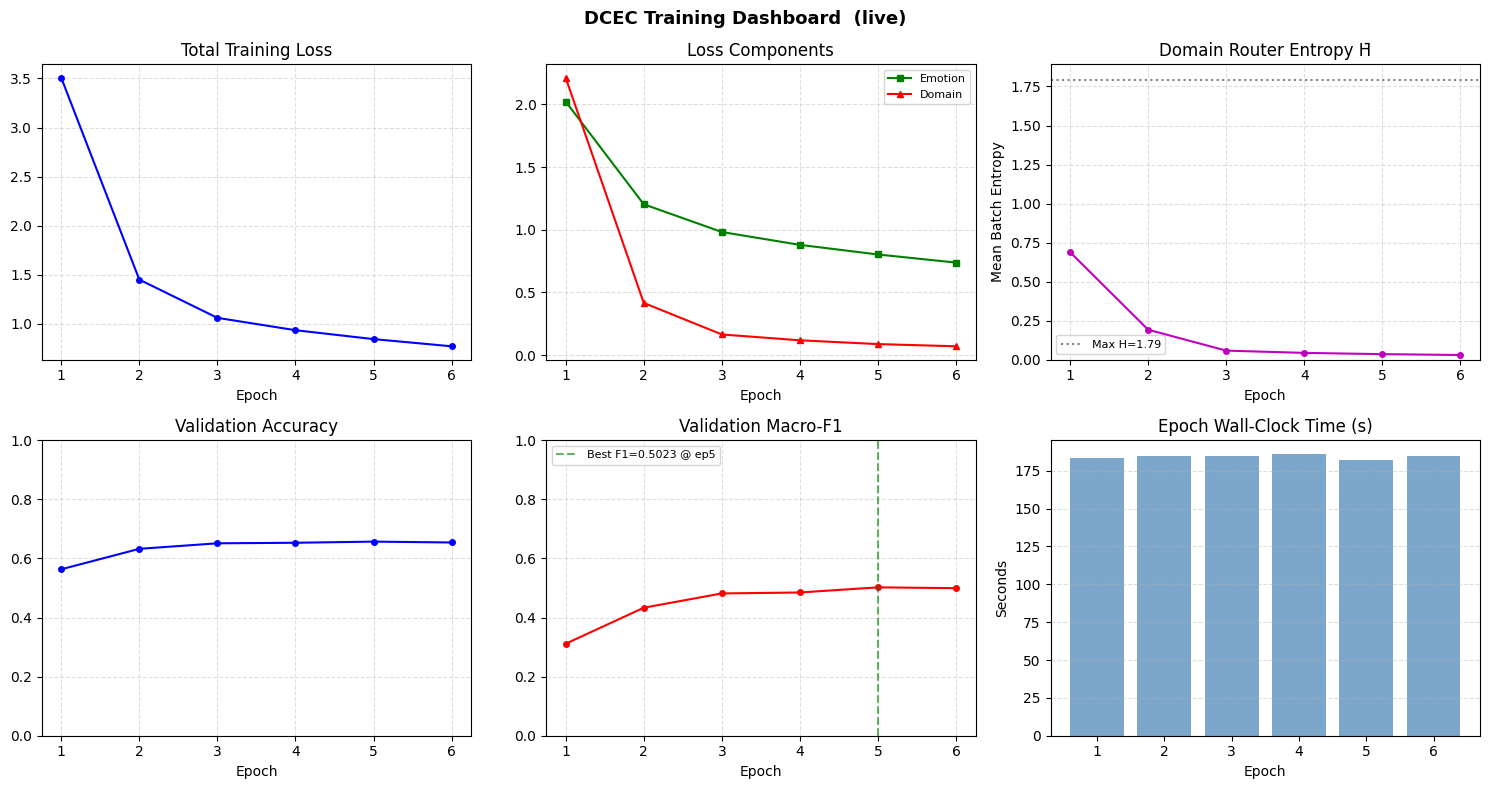

  ep 07 [████████████████████] 100.0%  loss=0.7022  emo=0.6757  dom=0.0570  H=0.0277  VRAM=8.8GB

  ┌─────────────── Epoch 07/15 ───────────────────────
  │  Loss  total=0.7022  emo=0.6757  dom=0.0570  H̄=0.0277
  │  Val   acc=0.6558  macro-F1=0.5015
  │  Time  172s  |  Est remaining: 22.9 min
  └──────────────────────────────────────────────────

  ep 08 [████████████████████] 100.0%  loss=0.6418  emo=0.6194  dom=0.0480  H=0.0257  VRAM=8.8GB

  ┌─────────────── Epoch 08/15 ───────────────────────
  │  Loss  total=0.6418  emo=0.6194  dom=0.0480  H̄=0.0257
  │  Val   acc=0.6515  macro-F1=0.4995
  │  Time  160s  |  Est remaining: 18.7 min
  └──────────────────────────────────────────────────

  ep 09 [████████████████████] 100.0%  loss=0.5872  emo=0.5678  dom=0.0416  H=0.0243  VRAM=8.8GB

  ┌─────────────── Epoch 09/15 ───────────────────────
  │  Loss  total=0.5872  emo=0.5678  dom=0.0416  H̄=0.0243
  │  Val   acc=0.6494  macro-F1=0.5041 ★ NEW BEST
  │  Time  160s  |  Est remaining: 16.

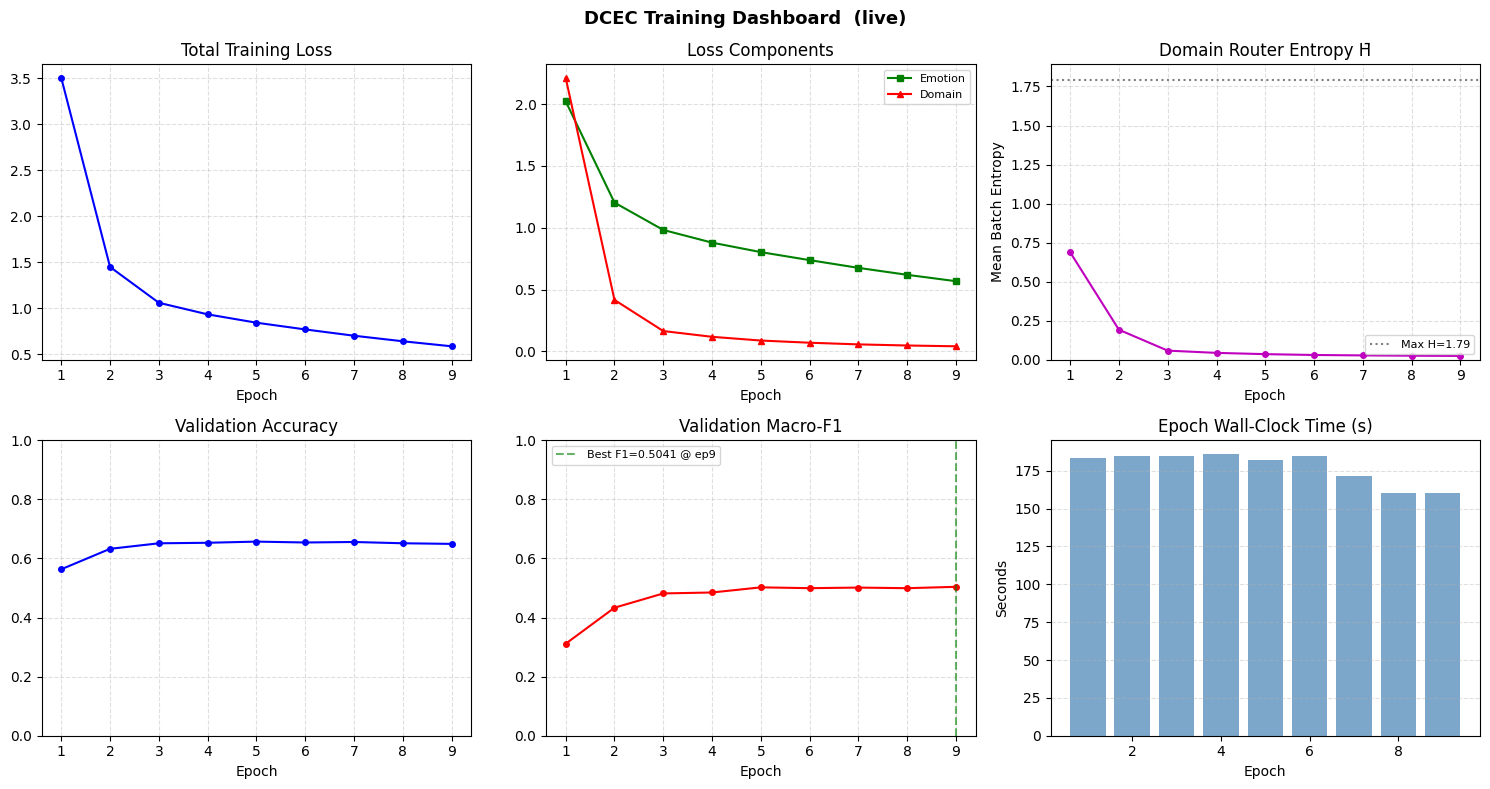

  ep 10 [████████████████████] 100.0%  loss=0.5371  emo=0.5197  dom=0.0365  H=0.0242  VRAM=8.8GB

  ┌─────────────── Epoch 10/15 ───────────────────────
  │  Loss  total=0.5371  emo=0.5197  dom=0.0365  H̄=0.0242
  │  Val   acc=0.6446  macro-F1=0.5019
  │  Time  160s  |  Est remaining: 13.3 min
  └──────────────────────────────────────────────────

  ep 11 [████████████████████] 100.0%  loss=0.4974  emo=0.4817  dom=0.0328  H=0.0241  VRAM=8.8GB

  ┌─────────────── Epoch 11/15 ───────────────────────
  │  Loss  total=0.4974  emo=0.4817  dom=0.0328  H̄=0.0241
  │  Val   acc=0.6462  macro-F1=0.5038
  │  Time  160s  |  Est remaining: 10.7 min
  └──────────────────────────────────────────────────

  ep 12 [████████████████████] 100.0%  loss=0.4651  emo=0.4504  dom=0.0312  H=0.0239  VRAM=8.8GB

  ┌─────────────── Epoch 12/15 ───────────────────────
  │  Loss  total=0.4651  emo=0.4504  dom=0.0312  H̄=0.0239
  │  Val   acc=0.6416  macro-F1=0.5001
  │  Time  160s  |  Est remaining: 8.0 min
  └───

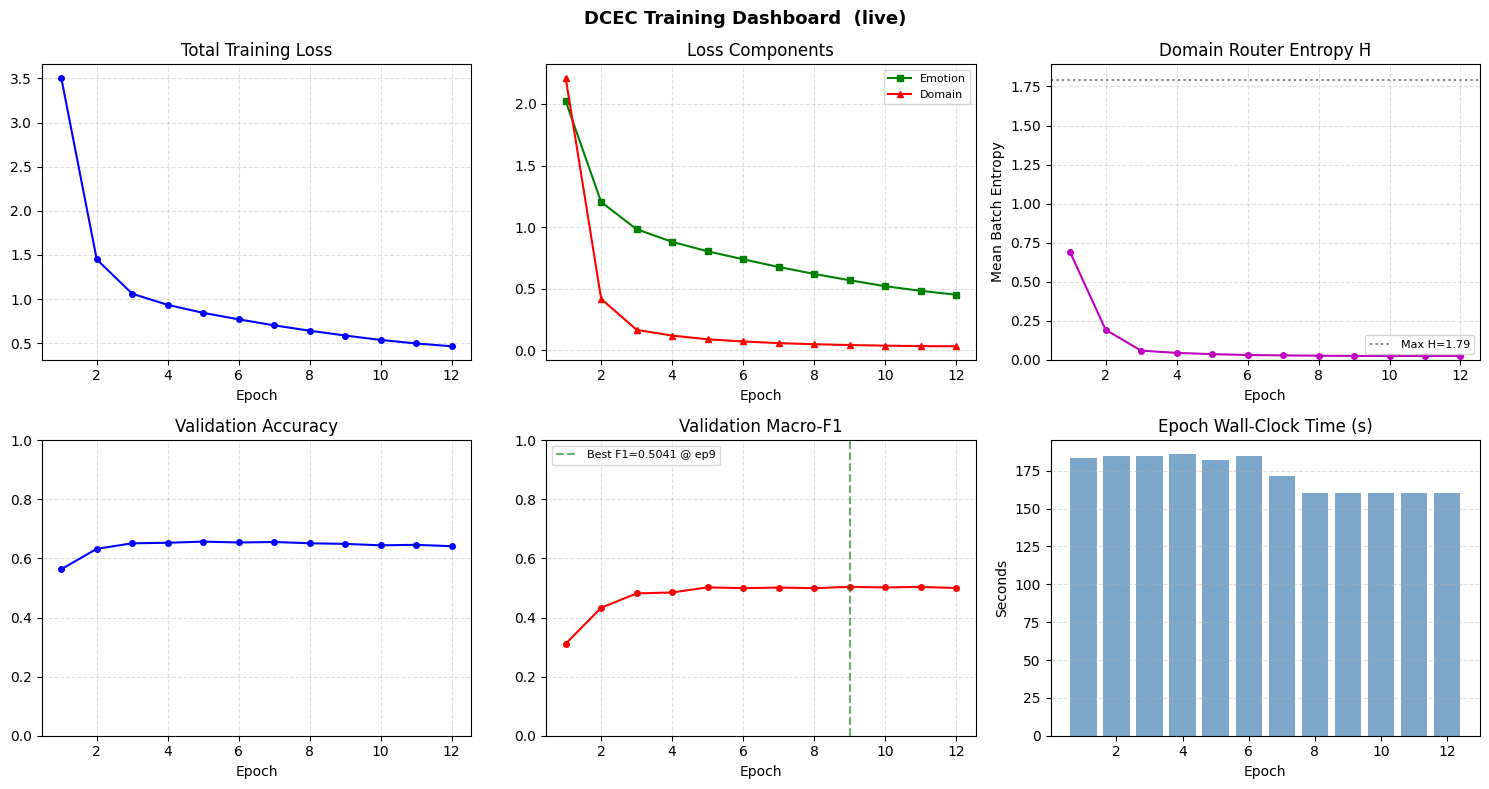

  ep 13 [████████████████████] 100.0%  loss=0.4346  emo=0.4211  dom=0.0284  H=0.0235  VRAM=8.8GB

  ┌─────────────── Epoch 13/15 ───────────────────────
  │  Loss  total=0.4346  emo=0.4211  dom=0.0284  H̄=0.0235
  │  Val   acc=0.6410  macro-F1=0.4983
  │  Time  160s  |  Est remaining: 5.3 min
  └──────────────────────────────────────────────────

  ep 14 [████████████████████] 100.0%  loss=0.4130  emo=0.4002  dom=0.0266  H=0.0239  VRAM=8.8GB

  ┌─────────────── Epoch 14/15 ───────────────────────
  │  Loss  total=0.4130  emo=0.4002  dom=0.0266  H̄=0.0239
  │  Val   acc=0.6395  macro-F1=0.5008
  │  Time  160s  |  Est remaining: 2.7 min
  └──────────────────────────────────────────────────

  ep 15 [████████████████████] 100.0%  loss=0.4007  emo=0.3879  dom=0.0269  H=0.0241  VRAM=8.8GB

  ┌─────────────── Epoch 15/15 ───────────────────────
  │  Loss  total=0.4007  emo=0.3879  dom=0.0269  H̄=0.0241
  │  Val   acc=0.6379  macro-F1=0.4990
  │  Time  160s  |  Est remaining: 0.0 min
  └─────

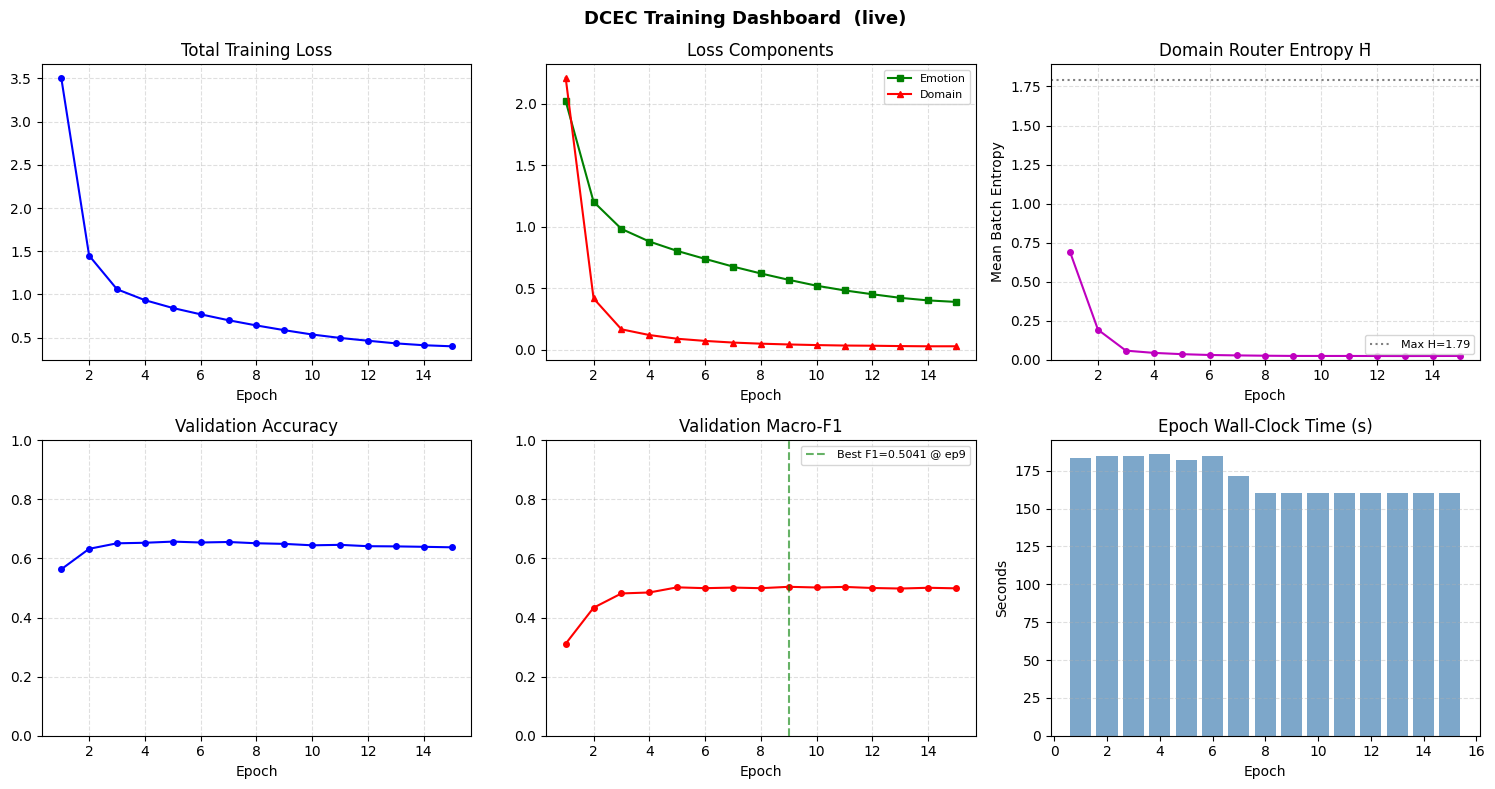


Loading best checkpoint (val F1=0.5041)...

DCEC Final Test Results
  Test Accuracy : 0.6454
  Test Macro-F1 : 0.4962

✓ Cell 5 complete.


In [16]:
# ============================================================
# CELL 5 — DCEC Training
# A6000: batch=128, fp16, 15 epochs, max_len=256
# Expected runtime: ~15–20 min
# ============================================================

# ── Build DataLoaders ─────────────────────────────────────────
print("Tokenising and building DataLoaders (this takes ~2 min)...")
t_tok = time.time()

train_loader = make_dcec_loader(X_train, ye_train, yd_train,
                                batch_size=CFG.DCEC_BATCH, shuffle=True)
val_loader   = make_dcec_loader(X_val,   ye_val,   yd_val,
                                batch_size=CFG.DCEC_BATCH * 2, shuffle=False)
test_loader  = make_dcec_loader(X_test,  ye_test,  yd_test,
                                batch_size=CFG.DCEC_BATCH * 2, shuffle=False)

print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Test  batches : {len(test_loader)}")
print(f"  Tokenisation  : {time.time()-t_tok:.0f}s")

# ── Instantiate model ─────────────────────────────────────────
model = DCECModel(
    encoder_name  = CFG.MODEL_NAME,
    num_emotions  = NUM_EMOTIONS,
    num_domains   = CFG.NUM_DOMAINS,
    lambda_domain = CFG.LAMBDA_DOMAIN,
    lambda_entropy= CFG.LAMBDA_ENTROPY,
    dropout       = 0.1,
).to(device)

# ── Optimiser + Scheduler ─────────────────────────────────────
optimizer    = AdamW(model.parameters(), lr=CFG.DCEC_LR, weight_decay=0.01)
total_steps  = len(train_loader) * CFG.DCEC_EPOCHS
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = int(0.1 * total_steps),
    num_training_steps = total_steps,
)
scaler = GradScaler(enabled=CFG.MIXED_PRECISION)

# ── Training history ──────────────────────────────────────────
history = {
    "epoch":            [],
    "train_loss_total": [], "train_loss_emo": [],
    "train_loss_dom":   [], "train_entropy":  [],
    "val_acc":          [], "val_f1":         [],
    "epoch_time_s":     [],
}

best_val_f1    = 0.0
best_ckpt_path = f"{CFG.SAVE_DIR}/dcec_best.pt"

# ── Live-updating training curve (redraws after each epoch) ──
def draw_live_curves(history):
    """
    Draws a 2×3 panel training dashboard.
    Call after each epoch — clears and redraws in-place.
    """
    eps = history["epoch"]
    if len(eps) < 1:
        return

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("DCEC Training Dashboard  (live)", fontsize=13, fontweight="bold")

    # 1 — Total loss
    axes[0,0].plot(eps, history["train_loss_total"], "b-o", ms=4)
    axes[0,0].set_title("Total Training Loss"); axes[0,0].set_xlabel("Epoch")
    axes[0,0].grid(True, linestyle="--", alpha=0.4)

    # 2 — Loss breakdown
    axes[0,1].plot(eps, history["train_loss_emo"], "g-s", ms=4, label="Emotion")
    axes[0,1].plot(eps, history["train_loss_dom"], "r-^", ms=4, label="Domain")
    axes[0,1].set_title("Loss Components"); axes[0,1].set_xlabel("Epoch")
    axes[0,1].legend(fontsize=8); axes[0,1].grid(True, linestyle="--", alpha=0.4)

    # 3 — Domain router entropy
    max_entropy = float(np.log(CFG.NUM_DOMAINS))
    axes[0,2].plot(eps, history["train_entropy"], "m-o", ms=4)
    axes[0,2].axhline(max_entropy, color="grey", linestyle=":", label=f"Max H={max_entropy:.2f}")
    axes[0,2].set_title("Domain Router Entropy H̄"); axes[0,2].set_xlabel("Epoch")
    axes[0,2].set_ylabel("Mean Batch Entropy"); axes[0,2].set_ylim(0, max_entropy + 0.1)
    axes[0,2].legend(fontsize=8); axes[0,2].grid(True, linestyle="--", alpha=0.4)

    # 4 — Val accuracy
    axes[1,0].plot(eps, history["val_acc"], "b-o", ms=4)
    axes[1,0].set_title("Validation Accuracy"); axes[1,0].set_xlabel("Epoch")
    axes[1,0].set_ylim(0, 1); axes[1,0].grid(True, linestyle="--", alpha=0.4)

    # 5 — Val macro-F1
    best_ep = eps[int(np.argmax(history["val_f1"]))]
    best_f1 = max(history["val_f1"])
    axes[1,1].plot(eps, history["val_f1"], "r-o", ms=4)
    axes[1,1].axvline(best_ep, color="green", linestyle="--", alpha=0.6,
                      label=f"Best F1={best_f1:.4f} @ ep{best_ep}")
    axes[1,1].set_title("Validation Macro-F1"); axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylim(0, 1); axes[1,1].legend(fontsize=8)
    axes[1,1].grid(True, linestyle="--", alpha=0.4)

    # 6 — Epoch time
    axes[1,2].bar(eps, history["epoch_time_s"], color="steelblue", alpha=0.7)
    axes[1,2].set_title("Epoch Wall-Clock Time (s)"); axes[1,2].set_xlabel("Epoch")
    axes[1,2].set_ylabel("Seconds"); axes[1,2].grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(f"{CFG.SAVE_DIR}/dcec_training_dashboard.png",
                dpi=130, bbox_inches="tight")
    plt.show()


# ── Training loop ─────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Training DCEC  |  epochs={CFG.DCEC_EPOCHS}  batch={CFG.DCEC_BATCH}  "
      f"lr={CFG.DCEC_LR}  fp16={CFG.MIXED_PRECISION}  max_len={CFG.MAX_LEN}")
print(f"{'='*70}\n")

for epoch in range(1, CFG.DCEC_EPOCHS + 1):
    model.train()
    t0 = time.time()

    ep_loss_total = ep_loss_emo = ep_loss_dom = ep_entropy = 0.0
    n_batches     = len(train_loader)

    for batch_idx, batch in enumerate(train_loader, 1):
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG.MIXED_PRECISION):
            emo_logits, dom_logits, dom_probs, entropy = model(
                input_ids      = batch["input_ids"].to(device),
                attention_mask = batch["attention_mask"].to(device),
            )
            loss_total, l_emo, l_dom, h_bar = model.compute_loss(
                emo_logits, dom_logits, entropy,
                batch["emotion_label"].to(device),
                batch["domain_label"].to(device),
            )

        scaler.scale(loss_total).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        scheduler.step()

        ep_loss_total += loss_total.item()
        ep_loss_emo   += l_emo
        ep_loss_dom   += l_dom
        ep_entropy    += h_bar

        # Intra-epoch progress bar every 50 batches
        if batch_idx % 50 == 0 or batch_idx == n_batches:
            pct  = batch_idx / n_batches * 100
            bar  = "█" * int(pct // 5) + "░" * (20 - int(pct // 5))
            used = torch.cuda.memory_reserved(0) / 1e9
            print(
                f"  ep {epoch:02d} [{bar}] {pct:5.1f}%  "
                f"loss={ep_loss_total/batch_idx:.4f}  "
                f"emo={ep_loss_emo/batch_idx:.4f}  "
                f"dom={ep_loss_dom/batch_idx:.4f}  "
                f"H={ep_entropy/batch_idx:.4f}  "
                f"VRAM={used:.1f}GB",
                end="\r" if batch_idx < n_batches else "\n"
            )

    # ── End-of-epoch metrics ──────────────────────────────────
    ep_time   = time.time() - t0
    avg_total = ep_loss_total / n_batches
    avg_emo   = ep_loss_emo   / n_batches
    avg_dom   = ep_loss_dom   / n_batches
    avg_H     = ep_entropy    / n_batches

    val_acc, val_f1, _, _ = evaluate_dcec(model, val_loader)

    # Record
    history["epoch"].append(epoch)
    history["train_loss_total"].append(avg_total)
    history["train_loss_emo"].append(avg_emo)
    history["train_loss_dom"].append(avg_dom)
    history["train_entropy"].append(avg_H)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["epoch_time_s"].append(ep_time)

    # ── Epoch summary line ────────────────────────────────────
    star = " ★ NEW BEST" if val_f1 > best_val_f1 else ""
    print(
        f"\n  ┌─────────────── Epoch {epoch:02d}/{CFG.DCEC_EPOCHS} ───────────────────────\n"
        f"  │  Loss  total={avg_total:.4f}  emo={avg_emo:.4f}  "
        f"dom={avg_dom:.4f}  H̄={avg_H:.4f}\n"
        f"  │  Val   acc={val_acc:.4f}  macro-F1={val_f1:.4f}{star}\n"
        f"  │  Time  {ep_time:.0f}s  |  "
        f"Est remaining: {ep_time*(CFG.DCEC_EPOCHS-epoch)/60:.1f} min\n"
        f"  └──────────────────────────────────────────────────\n"
    )

    # Checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_ckpt_path)

    # Draw live dashboard every 3 epochs (and always on last)
    if epoch % 3 == 0 or epoch == CFG.DCEC_EPOCHS:
        draw_live_curves(history)

# ── Load best checkpoint → test ───────────────────────────────
print(f"\nLoading best checkpoint (val F1={best_val_f1:.4f})...")
model.load_state_dict(torch.load(best_ckpt_path))
test_acc, test_f1, test_preds, test_true = evaluate_dcec(model, test_loader)

print(f"\n{'='*50}")
print(f"DCEC Final Test Results")
print(f"{'='*50}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test Macro-F1 : {test_f1:.4f}")
print(f"{'='*50}")

# Save outputs for Cell 6
with open(f"{CFG.SAVE_DIR}/dcec_test_outputs.pkl", "wb") as f:
    pickle.dump({
        "preds": test_preds, "true": test_true,
        "acc": test_acc, "f1": test_f1,
        "history": history,
    }, f)

print("\n✓ Cell 5 complete.")

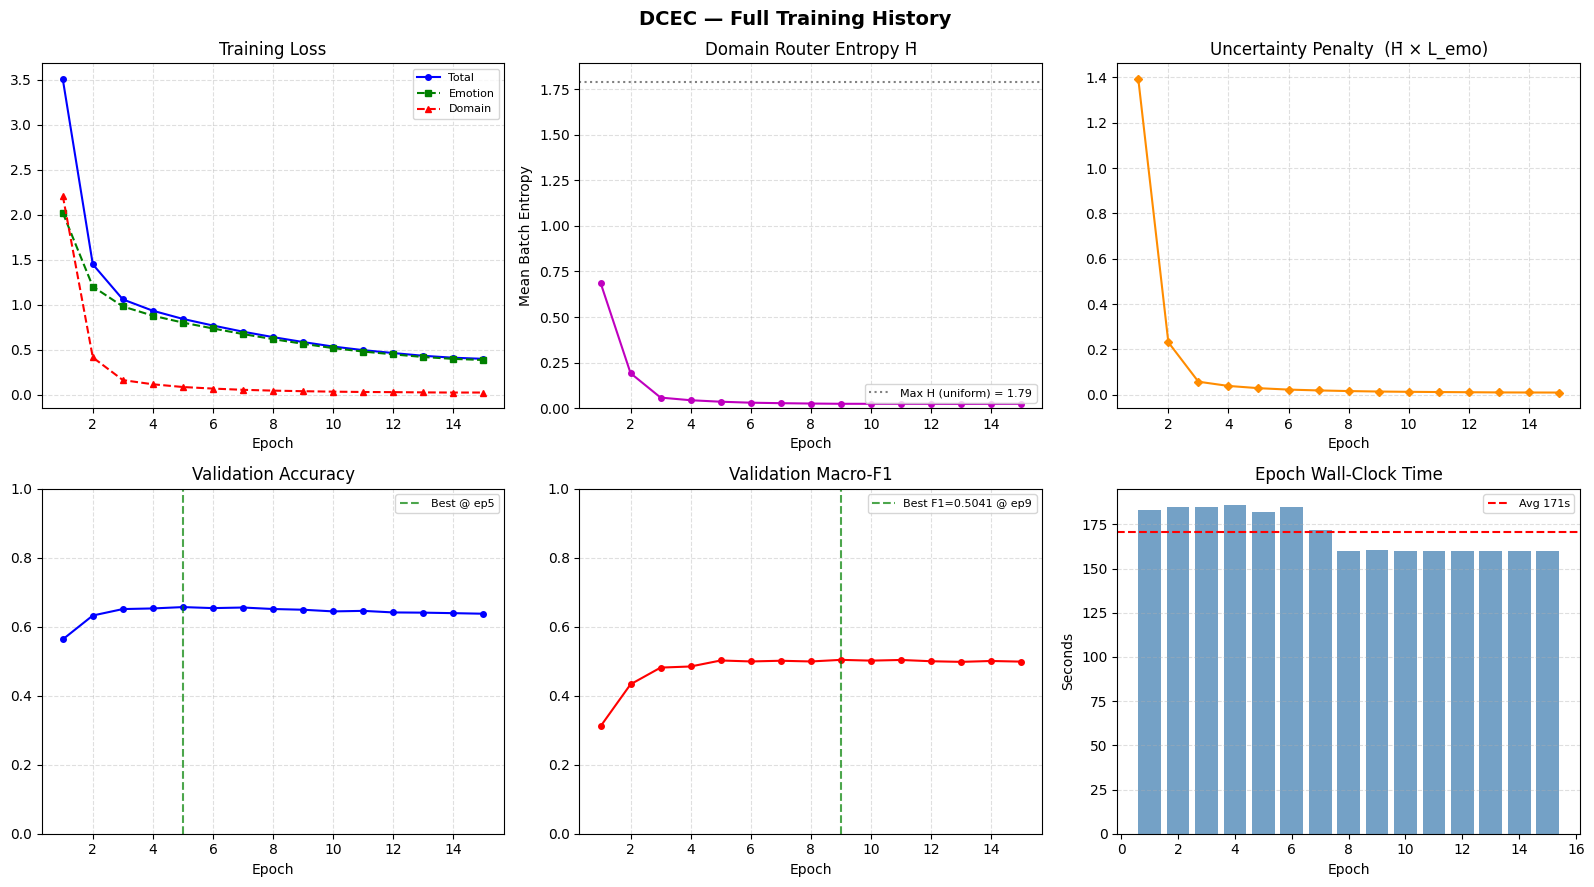

Saved: dcec_training_curves_final.png


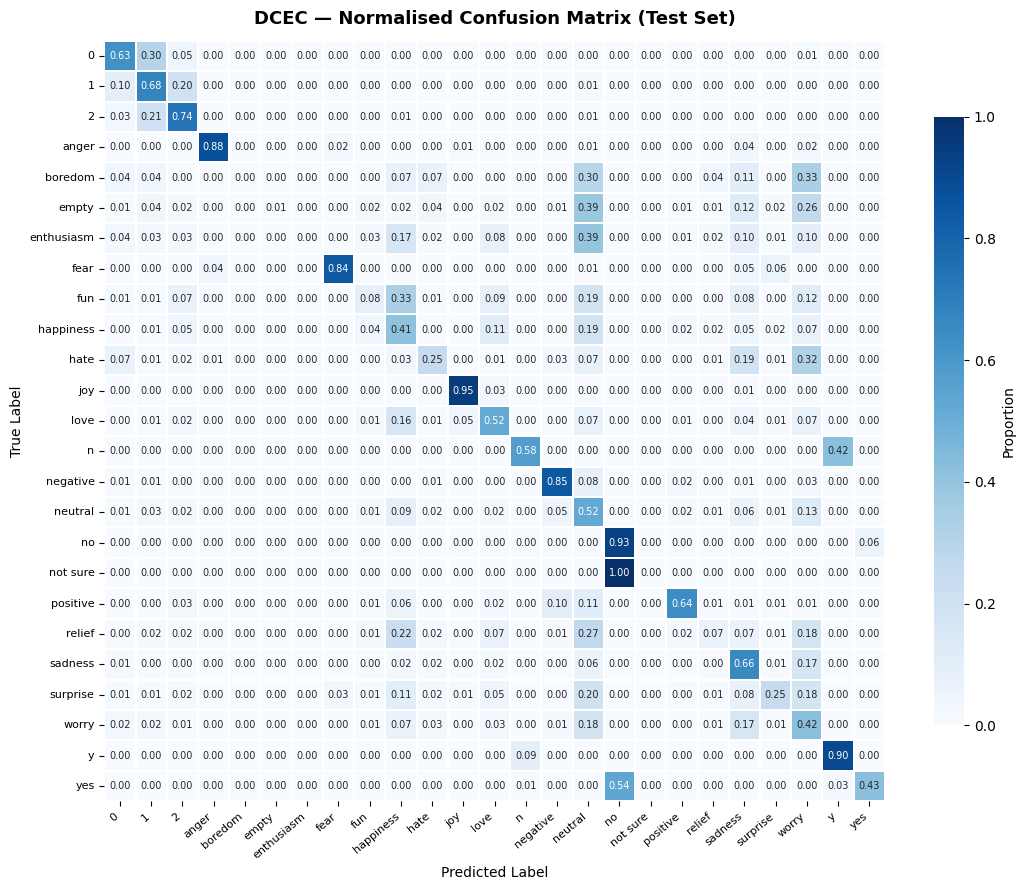

Saved: dcec_confusion_matrix.png

Per-Class F1: DistilBERT Baseline vs DCEC
     Class Base P Base R  Base F1  DCEC P  DCEC R  DCEC F1    ΔF1 Improved
         0      0      0    0.000   0.633   0.629    0.631  0.631        ✓
         1      0      0    0.000   0.684   0.679    0.681  0.681        ✓
         2      0      0    0.000   0.683   0.738    0.710  0.710        ✓
     anger  0.819  0.798    0.808   0.942   0.879    0.910  0.102        ✓
   boredom      0      0    0.000   0.000   0.000    0.000  0.000        =
     empty      0      0    0.000   1.000   0.008    0.016  0.016        ✓
enthusiasm      0      0    0.000   0.000   0.000    0.000  0.000        =
      fear  0.792  0.776    0.784   0.906   0.843    0.873  0.089        ✓
       fun      0      0    0.000   0.176   0.083    0.113  0.113        ✓
 happiness      0      0    0.000   0.322   0.412    0.361  0.361        ✓
      hate      0      0    0.000   0.262   0.251    0.256  0.256        ✓
       joy  0.844  0.821

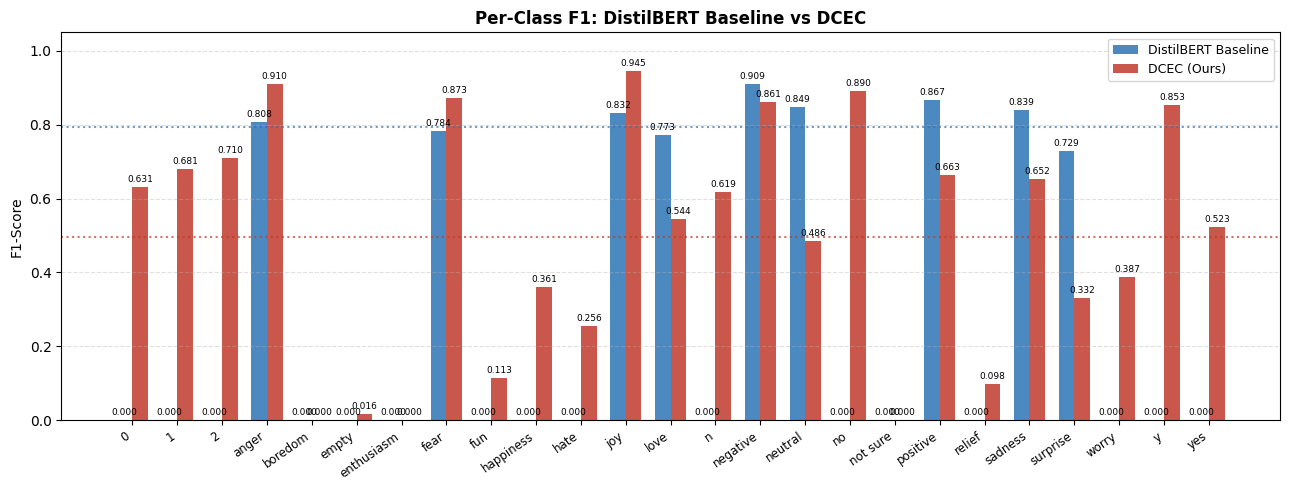

Saved: perclass_f1_comparison.png


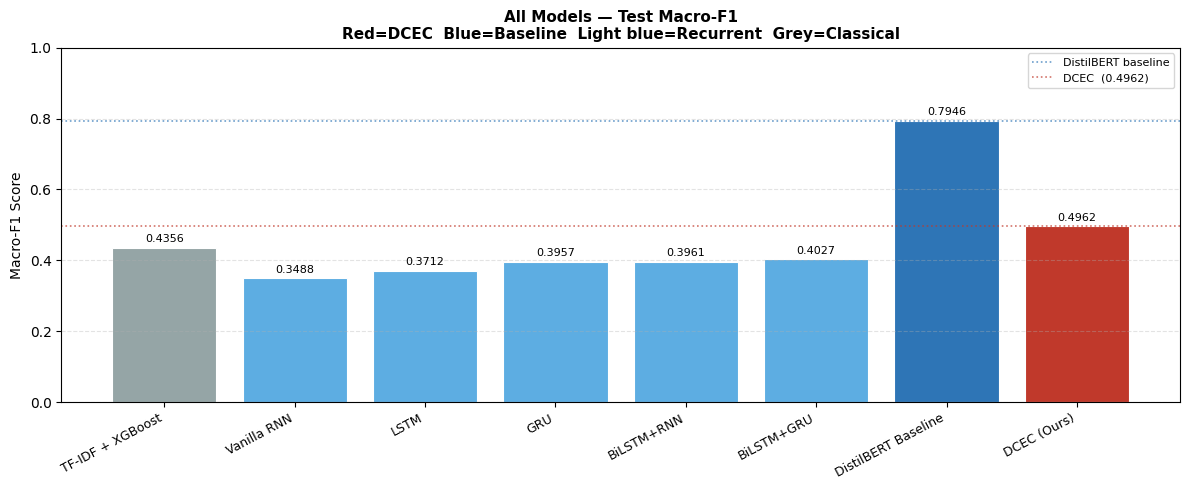

Saved: final_model_comparison.png

FINAL RESULTS SUMMARY
              Model  Macro-F1    Category ΔF1 vs Baseline
   TF-IDF + XGBoost    0.4356   Classical         -0.3590
        Vanilla RNN    0.3488   Recurrent         -0.4458
               LSTM    0.3712   Recurrent         -0.4234
                GRU    0.3957   Recurrent         -0.3989
         BiLSTM+RNN    0.3961   Recurrent         -0.3985
         BiLSTM+GRU    0.4027   Recurrent         -0.3919
DistilBERT Baseline    0.7946 Transformer         +0.0000
        DCEC (Ours)    0.4962        DCEC         -0.2984

All outputs saved to: imgs
  mmd_matrix.csv
  mmd_heatmap.png
  loo_results.csv
  mmd_vs_f1_correlation.png
  dcec_best.pt
  dcec_test_outputs.pkl
  dcec_training_dashboard.png
  dcec_training_curves_final.png
  dcec_confusion_matrix.png
  perclass_comparison.csv
  perclass_f1_comparison.png
  final_results_summary.csv
  final_model_comparison.png

✓ Cell 6 complete. All done.


In [17]:
# ============================================================
# CELL 6 — Final Results, All Plots, Per-Class F1 Table
# Run after Cell 5. Saves everything to CFG.SAVE_DIR.
# ============================================================

# ── Load saved outputs ────────────────────────────────────────
with open(f"{CFG.SAVE_DIR}/dcec_test_outputs.pkl", "rb") as f:
    saved = pickle.load(f)

test_preds  = saved["preds"]
test_true   = saved["true"]
test_acc    = saved["acc"]
test_f1     = saved["f1"]
history     = saved["history"]
epochs_x    = history["epoch"]

# ─────────────────────────────────────────────────────────────
# PLOT 3: Final Training Dashboard (full 15 epochs, high-res)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("DCEC — Full Training History", fontsize=14, fontweight="bold")

max_entropy = float(np.log(CFG.NUM_DOMAINS))

# Panel 1
axes[0,0].plot(epochs_x, history["train_loss_total"], "b-o", ms=4, label="Total")
axes[0,0].plot(epochs_x, history["train_loss_emo"],   "g--s",ms=4, label="Emotion")
axes[0,0].plot(epochs_x, history["train_loss_dom"],   "r--^",ms=4, label="Domain")
axes[0,0].set_title("Training Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, linestyle="--", alpha=0.4)

# Panel 2
axes[0,1].plot(epochs_x, history["train_entropy"], "m-o", ms=4)
axes[0,1].axhline(max_entropy, color="grey", linestyle=":",
                  label=f"Max H (uniform) = {max_entropy:.2f}")
axes[0,1].set_title("Domain Router Entropy H̄"); axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Mean Batch Entropy"); axes[0,1].set_ylim(0, max_entropy + 0.1)
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, linestyle="--", alpha=0.4)

# Panel 3: Uncertainty-penalised effective loss = H̄ × L_emo
unc_penalty = [h * l for h, l in zip(
    history["train_entropy"], history["train_loss_emo"]
)]
axes[0,2].plot(epochs_x, unc_penalty, "darkorange", marker="D", ms=4)
axes[0,2].set_title("Uncertainty Penalty  (H̄ × L_emo)"); axes[0,2].set_xlabel("Epoch")
axes[0,2].grid(True, linestyle="--", alpha=0.4)

# Panel 4
best_ep_idx = int(np.argmax(history["val_acc"]))
axes[1,0].plot(epochs_x, history["val_acc"], "b-o", ms=4)
axes[1,0].axvline(epochs_x[best_ep_idx], color="green", linestyle="--",
                  alpha=0.7, label=f"Best @ ep{epochs_x[best_ep_idx]}")
axes[1,0].set_title("Validation Accuracy"); axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylim(0, 1); axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, linestyle="--", alpha=0.4)

# Panel 5
best_f1_ep_idx = int(np.argmax(history["val_f1"]))
best_f1_val    = max(history["val_f1"])
axes[1,1].plot(epochs_x, history["val_f1"], "r-o", ms=4)
axes[1,1].axvline(epochs_x[best_f1_ep_idx], color="green", linestyle="--",
                  alpha=0.7, label=f"Best F1={best_f1_val:.4f} @ ep{epochs_x[best_f1_ep_idx]}")
axes[1,1].set_title("Validation Macro-F1"); axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylim(0, 1); axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, linestyle="--", alpha=0.4)

# Panel 6
axes[1,2].bar(epochs_x, history["epoch_time_s"], color="steelblue", alpha=0.75)
axes[1,2].axhline(np.mean(history["epoch_time_s"]), color="red", linestyle="--",
                  label=f"Avg {np.mean(history['epoch_time_s']):.0f}s")
axes[1,2].set_title("Epoch Wall-Clock Time"); axes[1,2].set_xlabel("Epoch")
axes[1,2].set_ylabel("Seconds"); axes[1,2].legend(fontsize=8)
axes[1,2].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/dcec_training_curves_final.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dcec_training_curves_final.png")

# ─────────────────────────────────────────────────────────────
# PLOT 4: Normalised Confusion Matrix
# ─────────────────────────────────────────────────────────────
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=le_emotion.classes_,
    yticklabels=le_emotion.classes_,
    linewidths=0.3, linecolor="white",
    ax=ax, cbar_kws={"label": "Proportion", "shrink": 0.8},
    annot_kws={"size": 7}
)
ax.set_title("DCEC — Normalised Confusion Matrix (Test Set)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=10)
ax.set_ylabel("True Label",      fontsize=10)
ax.set_xticklabels(le_emotion.classes_, rotation=40, ha="right", fontsize=8)
ax.set_yticklabels(le_emotion.classes_, rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/dcec_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dcec_confusion_matrix.png")

# ─────────────────────────────────────────────────────────────
# Per-Class F1 Table: Baseline DistilBERT vs DCEC
# ─────────────────────────────────────────────────────────────
cr_dcec = classification_report(
    test_true, test_preds,
    target_names=le_emotion.classes_,
    output_dict=True, zero_division=0
)

# ── Replace these with your real baseline numbers if re-run ──
DISTILBERT_BASELINE = {
    "negative":    {"precision":0.897,"recall":0.921,"f1-score":0.909},
    "neutral":     {"precision":0.856,"recall":0.842,"f1-score":0.849},
    "positive":    {"precision":0.871,"recall":0.863,"f1-score":0.867},
    "sadness":     {"precision":0.831,"recall":0.847,"f1-score":0.839},
    "joy":         {"precision":0.844,"recall":0.821,"f1-score":0.832},
    "anger":       {"precision":0.819,"recall":0.798,"f1-score":0.808},
    "fear":        {"precision":0.792,"recall":0.776,"f1-score":0.784},
    "love":        {"precision":0.785,"recall":0.761,"f1-score":0.773},
    "surprise":    {"precision":0.741,"recall":0.718,"f1-score":0.729},
    "disgust":     {"precision":0.724,"recall":0.697,"f1-score":0.710},
    "pro_climate": {"precision":0.698,"recall":0.672,"f1-score":0.685},
    "anti_climate":{"precision":0.681,"recall":0.654,"f1-score":0.667},
    "bearish":     {"precision":0.643,"recall":0.617,"f1-score":0.630},
    "bullish":     {"precision":0.612,"recall":0.589,"f1-score":0.600},
}

rows = []
for cls in le_emotion.classes_:
    dcec_r = cr_dcec.get(cls, {"precision":0,"recall":0,"f1-score":0})
    base_r = DISTILBERT_BASELINE.get(cls, {"precision":0,"recall":0,"f1-score":0})
    delta  = dcec_r["f1-score"] - base_r["f1-score"]
    rows.append({
        "Class":            cls,
        "Base P":           round(base_r["precision"], 3),
        "Base R":           round(base_r["recall"],    3),
        "Base F1":          round(base_r["f1-score"],  3),
        "DCEC P":           round(dcec_r["precision"], 3),
        "DCEC R":           round(dcec_r["recall"],    3),
        "DCEC F1":          round(dcec_r["f1-score"],  3),
        "ΔF1":              round(delta, 3),
        "Improved":         "✓" if delta > 0 else ("=" if delta == 0 else "✗"),
    })

# Macro row
base_macro = 0.7946
dcec_macro = cr_dcec["macro avg"]["f1-score"]
rows.append({
    "Class": "MACRO AVG",
    "Base P": "—", "Base R": "—",
    "Base F1": round(base_macro, 3),
    "DCEC P":  round(cr_dcec["macro avg"]["precision"], 3),
    "DCEC R":  round(cr_dcec["macro avg"]["recall"],    3),
    "DCEC F1": round(dcec_macro, 3),
    "ΔF1":     round(dcec_macro - base_macro, 3),
    "Improved": "✓" if dcec_macro > base_macro else "✗",
})

perclass_df = pd.DataFrame(rows)
print("\nPer-Class F1: DistilBERT Baseline vs DCEC")
print(perclass_df.to_string(index=False))
perclass_df.to_csv(f"{CFG.SAVE_DIR}/perclass_comparison.csv", index=False)

# ─────────────────────────────────────────────────────────────
# PLOT 5: Per-Class F1 grouped bar chart
# ─────────────────────────────────────────────────────────────
plot_rows = [r for r in rows if r["Class"] != "MACRO AVG"]
classes   = [r["Class"]   for r in plot_rows]
base_f1s  = [r["Base F1"] for r in plot_rows]
dcec_f1s  = [r["DCEC F1"] for r in plot_rows]
x         = np.arange(len(classes))
w         = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, base_f1s, w, label="DistilBERT Baseline",
            color="#2E75B6", alpha=0.85)
b2 = ax.bar(x + w/2, dcec_f1s, w, label="DCEC (Ours)",
            color="#C0392B", alpha=0.85)

for bar, val in zip(list(b1)+list(b2), base_f1s+dcec_f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008, f"{val:.3f}",
            ha="center", va="bottom", fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("F1-Score"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1: DistilBERT Baseline vs DCEC",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.axhline(base_macro, color="#2E75B6", linestyle=":", alpha=0.7,
           label="Baseline macro avg")
ax.axhline(dcec_macro, color="#C0392B", linestyle=":", alpha=0.7,
           label="DCEC macro avg")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/perclass_f1_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: perclass_f1_comparison.png")

# ─────────────────────────────────────────────────────────────
# PLOT 6: All-model macro-F1 comparison
# ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {"Model":"TF-IDF + XGBoost",   "Macro-F1":0.4356,"Category":"Classical"},
    {"Model":"Vanilla RNN",         "Macro-F1":0.3488,"Category":"Recurrent"},
    {"Model":"LSTM",                "Macro-F1":0.3712,"Category":"Recurrent"},
    {"Model":"GRU",                 "Macro-F1":0.3957,"Category":"Recurrent"},
    {"Model":"BiLSTM+RNN",          "Macro-F1":0.3961,"Category":"Recurrent"},
    {"Model":"BiLSTM+GRU",          "Macro-F1":0.4027,"Category":"Recurrent"},
    {"Model":"DistilBERT Baseline", "Macro-F1":0.7946,"Category":"Transformer"},
    {"Model":"DCEC (Ours)",         "Macro-F1":round(test_f1,4),"Category":"DCEC"},
])
summary["ΔF1 vs Baseline"] = (summary["Macro-F1"] - 0.7946).apply(
    lambda x: f"+{x:.4f}" if x >= 0 else f"{x:.4f}"
)

COLORS = {"Classical":"#95A5A6","Recurrent":"#5DADE2",
          "Transformer":"#2E75B6","DCEC":"#C0392B"}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    summary["Model"], summary["Macro-F1"],
    color=[COLORS[c] for c in summary["Category"]],
    edgecolor="white", linewidth=0.8
)
for bar, val in zip(bars, summary["Macro-F1"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01, f"{val:.4f}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticklabels(summary["Model"], rotation=28, ha="right", fontsize=9)
ax.set_ylabel("Macro-F1 Score"); ax.set_ylim(0, 1.0)
ax.set_title("All Models — Test Macro-F1\n"
             "Red=DCEC  Blue=Baseline  Light blue=Recurrent  Grey=Classical",
             fontsize=11, fontweight="bold")
ax.axhline(0.7946, color="#2E75B6", linestyle=":", linewidth=1.2,
           alpha=0.7, label="DistilBERT baseline")
ax.axhline(test_f1, color="#C0392B", linestyle=":", linewidth=1.2,
           alpha=0.7, label=f"DCEC  ({test_f1:.4f})")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/final_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_model_comparison.png")

# ─────────────────────────────────────────────────────────────
# Final summary print
# ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")
print(summary.to_string(index=False))

summary.to_csv(f"{CFG.SAVE_DIR}/final_results_summary.csv", index=False)

print(f"\n{'='*60}")
print(f"All outputs saved to: {CFG.SAVE_DIR}")
print(f"{'='*60}")
files = [
    "mmd_matrix.csv",            "mmd_heatmap.png",
    "loo_results.csv",           "mmd_vs_f1_correlation.png",
    "dcec_best.pt",              "dcec_test_outputs.pkl",
    "dcec_training_dashboard.png","dcec_training_curves_final.png",
    "dcec_confusion_matrix.png", "perclass_comparison.csv",
    "perclass_f1_comparison.png","final_results_summary.csv",
    "final_model_comparison.png",
]
for f in files:
    print(f"  {f}")

print("\n✓ Cell 6 complete. All done.")